# Homework 2 — Reproducible Final Analysis

This notebook is the clean, top-to-bottom reproduction path for the final Homework 2 findings.

**Run order:** restart the kernel, then run all cells from top to bottom.

**Causal rules used throughout**
- TRAIN/TEST split is by match.
- Kalshi tape features use a 100 ms visibility buffer.
- External feeds are available only at collector receipt time unless Part 4 explicitly applies a counterfactual speedup.
- Book targets/marks require a valid book and maximum 3 s quote age.
- Model tuning and policy thresholds are chosen on TRAIN; TEST is held out for evaluation.


## 0. Setup and data

In [1]:
from pathlib import Path
import os
import sys
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()

if (cwd / "data").exists() and (cwd / "code").exists():
    PROJECT_DIR = cwd
elif (cwd.parent / "data").exists() and (cwd.parent / "code").exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError("Could not find the homework2 project folder.")

DATA_DIR = PROJECT_DIR / "data"
CODE_DIR = PROJECT_DIR / "code"
RESULTS_DIR = PROJECT_DIR / "results"

os.chdir(PROJECT_DIR)

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import starter
import mm_core

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())


import platform
import sklearn

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)


PROJECT_DIR: c:\Users\ishan\Downloads\homework2
DATA_DIR exists: True
Python: 3.13.3
pandas: 2.2.3
numpy: 2.2.5
scikit-learn: 1.7.2


In [2]:
trades = pd.read_parquet(DATA_DIR / "kalshi_trades.parquet")
bbo = pd.read_parquet(DATA_DIR / "kalshi_bbo.parquet")
book_quality = pd.read_parquet(DATA_DIR / "book_quality.parquet")
map_esports = pd.read_parquet(DATA_DIR / "map_esports.parquet")
map_mlb = pd.read_parquet(DATA_DIR / "map_mlb.parquet")
beter_trading_raw = pd.read_parquet(DATA_DIR / "beter_esports_trading.parquet")
beter_incident_raw = pd.read_parquet(DATA_DIR / "beter_esports_incident.parquet")
sr = pd.read_parquet(DATA_DIR / "sportradar_mlb_events.parquet")

cs2_map = map_esports[map_esports["sport_id"] == 3].copy()

print("Core files loaded.")

Core files loaded.


## 1. Shared helpers and causal market data

In [3]:
VISIBILITY_NS = 100_000_000
MAX_BOOK_AGE_S = 3.0

def prepare_axis_trades(sport):
    axis = starter.trades_on_axis(sport)

    if sport.lower() == "esports":
        axis = axis[axis["ticker"].str.startswith("KXCS2GAME")].copy()

    return (
        axis[axis["inplay"]]
        .sort_values(["match_id", "t_ns"])
        .reset_index(drop=True)
    )

def prepare_book(sport):
    out = bbo[bbo["sport"] == sport].copy()
    out["book_mid"] = (out["bid"] + out["ask"]) / 2

    quality = (
        book_quality.loc[
            book_quality["sport"] == sport,
            ["event_ticker", "book_ok"]
        ]
        .drop_duplicates("event_ticker")
    )

    out = out.merge(quality, on="event_ticker", how="left")
    out["book_ok"] = out["book_ok"].fillna(False)
    out["book_t_ns"] = out["t_ns"]

    return out.sort_values(["match_id", "t_ns"]).reset_index(drop=True)

def fit_blend_weight(df, mid_col, feed_col, y_col="y"):
    mid = df[mid_col].to_numpy(float)
    feed = df[feed_col].to_numpy(float)
    y = df[y_col].to_numpy(float)

    d = feed - mid
    denom = np.sum(d ** 2)

    if denom == 0:
        return np.nan

    w = np.sum(d * (y - mid)) / denom
    return float(np.clip(w, 0, 1))

def forecast_metrics(df, forecast_col, y_col="y"):
    e = df[forecast_col] - df[y_col]
    return {
        "n": len(df),
        "matches": df["match_id"].nunique(),
        "bias": e.mean(),
        "brier": np.mean(e ** 2),
        "rmse": np.sqrt(np.mean(e ** 2))
    }

def estimate_t50(path, sec_col="sec", fraction_col="fraction_of_10s_move"):
    d = path[[sec_col, fraction_col]].dropna().sort_values(sec_col)

    if len(d) == 0:
        return np.nan

    x = d[sec_col].to_numpy(float)
    y = d[fraction_col].to_numpy(float)

    for i in range(len(d)):
        if y[i] >= 0.5:
            if i == 0:
                return x[i]

            x0, x1 = x[i - 1], x[i]
            y0, y1 = y[i - 1], y[i]

            if y1 == y0:
                return x1

            return x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)

    return np.nan

In [4]:
cs2_inplay = prepare_axis_trades("esports")
mlb_inplay = prepare_axis_trades("mlb")

cs2_book = prepare_book("CS2")
mlb_book = prepare_book("MLB")

cs2_test_ids = set(starter.test_match_ids("esports"))
mlb_test_ids = set(str(x) for x in starter.test_match_ids("mlb"))

cs2_inplay["split"] = np.where(
    cs2_inplay["match_id"].isin(cs2_test_ids),
    "TEST",
    "TRAIN"
)

mlb_inplay["match_id"] = mlb_inplay["match_id"].astype(str)
mlb_book["match_id"] = mlb_book["match_id"].astype(str)

mlb_inplay["split"] = np.where(
    mlb_inplay["match_id"].isin(mlb_test_ids),
    "TEST",
    "TRAIN"
)

print("CS2 in-play rows:", len(cs2_inplay))
print("MLB in-play rows:", len(mlb_inplay))

CS2 in-play rows: 391664
MLB in-play rows: 1616549


## 2. Part 1 — Causal tape midpoint benchmark

These cells reproduce the final 1-second-grid tape estimators used as the causal market baseline.


In [5]:
def build_trade_states(trade_df, rolling_window, alpha):
    x = trade_df.sort_values(["match_id", "t_ns"]).copy()

    x["rolling_mid"] = (
        x.groupby("match_id", group_keys=False)["px"]
        .transform(lambda s: s.rolling(rolling_window, min_periods=1).mean())
    )

    x["ewma_mid"] = (
        x.groupby("match_id", group_keys=False)["px"]
        .transform(lambda s: s.ewm(alpha=alpha, adjust=False).mean())
    )

    x["trade_t_ns"] = x["t_ns"]
    return x

def make_second_grid(trade_df):
    pieces = []

    for match_id, g in trade_df.groupby("match_id", sort=False):
        lo = int(g["t_ns"].min())
        hi = int(g["t_ns"].max())

        start = ((lo + 999_999_999) // 1_000_000_000) * 1_000_000_000
        end = (hi // 1_000_000_000) * 1_000_000_000

        if start > end:
            continue

        pieces.append(pd.DataFrame({
            "match_id": match_id,
            "grid_t_ns": np.arange(
                start,
                end + 1_000_000_000,
                1_000_000_000,
                dtype=np.int64
            )
        }))

    return pd.concat(pieces, ignore_index=True)

def rebuild_part1_grid(trade_df, book_df, rolling_window, alpha, adjustment):
    trade_states = build_trade_states(
        trade_df,
        rolling_window=rolling_window,
        alpha=alpha
    )

    grid = make_second_grid(trade_df)
    grid["safe_t_ns"] = grid["grid_t_ns"] - VISIBILITY_NS

    tape_join = starter.asof(
        left=grid,
        right=trade_states,
        left_t="safe_t_ns",
        right_t="t_ns",
        by="match_id",
        cols=["px", "dir", "rolling_mid", "ewma_mid", "trade_t_ns", "split"]
    )

    grid[
        ["last_px", "last_dir", "rolling_mid", "ewma_mid", "trade_t_ns", "split"]
    ] = tape_join

    book_join = starter.asof(
        left=grid,
        right=book_df,
        left_t="grid_t_ns",
        right_t="t_ns",
        by="match_id",
        cols=["book_mid", "book_t_ns", "book_ok"]
    )

    grid[["book_mid", "book_t_ns", "book_ok"]] = book_join
    grid["book_age_s"] = (grid["grid_t_ns"] - grid["book_t_ns"]) / 1e9

    grid["valid_book"] = (
        grid["book_ok"].fillna(False)
        & grid["book_mid"].notna()
        & grid["book_age_s"].between(0, MAX_BOOK_AGE_S)
    )

    grid["est_rolling"] = grid["rolling_mid"]
    grid["est_ewma"] = grid["ewma_mid"]
    grid["est_aggressor"] = grid["last_px"] - adjustment * grid["last_dir"]

    return grid

def part1_metrics(grid):
    rows = []

    for name, col in {
        "Rolling": "est_rolling",
        "EWMA": "est_ewma",
        "Aggressor adjusted": "est_aggressor"
    }.items():
        d = grid[
            (grid["split"] == "TEST")
            & grid["valid_book"]
            & grid[col].notna()
        ].copy()

        e = d[col] - d["book_mid"]

        rows.append({
            "estimator": name,
            "n": len(d),
            "matches": d["match_id"].nunique(),
            "rmse": np.sqrt(np.mean(e ** 2)),
            "bias": e.mean()
        })

    return pd.DataFrame(rows).sort_values("rmse")

In [6]:
cs2_grid = rebuild_part1_grid(
    cs2_inplay,
    cs2_book,
    rolling_window=1,
    alpha=0.6,
    adjustment=0.01
)

mlb_grid = rebuild_part1_grid(
    mlb_inplay,
    mlb_book,
    rolling_window=5,
    alpha=0.4,
    adjustment=0.005
)

print("CS2 TEST")
display(part1_metrics(cs2_grid))

print("MLB TEST")
display(part1_metrics(mlb_grid))

C:\Users\ishan\AppData\Local\Temp\ipykernel_34024\4293420028.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grid["book_ok"].fillna(False)


CS2 TEST


,estimator,n,matches,rmse,bias
2,Aggressor adjusted,147641,28,0.019607,-0.000291
1,EWMA,147641,28,0.020820,-0.000056
0,Rolling,147641,28,0.022039,-0.000074


MLB TEST


,estimator,n,matches,rmse,bias
2,Aggressor adjusted,287489,31,0.004800,-0.000034
1,EWMA,287489,31,0.005308,-0.000341
0,Rolling,287489,31,0.005494,-0.000313


## 3. Part 2 — External-feed fair values

In [7]:
def attach_causal_tape_mid(
    left,
    trade_df,
    left_time_col,
    adjustment,
    out_col="tape_mid",
    visibility_ns=VISIBILITY_NS
):
    x = left.reset_index(drop=True).copy()
    x["safe_t_ns"] = x[left_time_col].astype("int64") - visibility_ns

    right = (
        trade_df[["match_id", "t_ns", "px", "dir"]]
        .sort_values(["match_id", "t_ns"])
        .copy()
    )
    right["mid_t_ns"] = right["t_ns"]

    joined = starter.asof(
        left=x,
        right=right,
        left_t="safe_t_ns",
        right_t="t_ns",
        by="match_id",
        cols=["px", "dir", "mid_t_ns"]
    )

    x[["last_px", "last_dir", "mid_t_ns"]] = joined
    x[out_col] = x["last_px"] - adjustment * x["last_dir"]
    x["mid_age_s"] = (x[left_time_col] - x["mid_t_ns"]) / 1e9

    return x

In [8]:
beter_mw = starter.beter_match_winner()

beter_live = beter_mw[
    (beter_mw["line_type"] == 1)
    & (beter_mw["st1"] == 1)
].copy()

cs2_p2 = attach_causal_tape_mid(
    beter_live,
    cs2_inplay,
    left_time_col="t_recv_ns",
    adjustment=0.01
)

cs2_results = (
    cs2_map[["beter_match_id", "result_team1"]]
    .rename(columns={"beter_match_id": "match_id"})
)

cs2_p2 = cs2_p2.merge(cs2_results, on="match_id", how="left")

cs2_p2["y"] = np.where(
    cs2_p2["result_team1"] == "yes",
    1.0,
    np.where(cs2_p2["result_team1"] == "no", 0.0, np.nan)
)

cs2_p2["split"] = np.where(
    cs2_p2["match_id"].isin(cs2_test_ids),
    "TEST",
    "TRAIN"
)

cs2_p2 = cs2_p2[
    cs2_p2["tape_mid"].notna()
    & cs2_p2["p1"].notna()
    & cs2_p2["y"].notna()
].copy()

cs2_p2["feed_minus_mid"] = cs2_p2["p1"] - cs2_p2["tape_mid"]

cs2_p2_train = cs2_p2[cs2_p2["split"] == "TRAIN"].copy()
cs2_p2_test = cs2_p2[cs2_p2["split"] == "TEST"].copy()

CS2_WEIGHT_REFIT = fit_blend_weight(
    cs2_p2_train,
    mid_col="tape_mid",
    feed_col="p1"
)

CS2_BETER_WEIGHT_FROZEN = 0.8253932284520029

cs2_p2_test["blend"] = (
    (1 - CS2_BETER_WEIGHT_FROZEN) * cs2_p2_test["tape_mid"]
    + CS2_BETER_WEIGHT_FROZEN * cs2_p2_test["p1"]
)

print("Refit TRAIN weight:", CS2_WEIGHT_REFIT)
print("Frozen final weight:", CS2_BETER_WEIGHT_FROZEN)

display(pd.DataFrame([
    {"forecast": "Tape", **forecast_metrics(cs2_p2_test, "tape_mid")},
    {"forecast": "BETER", **forecast_metrics(cs2_p2_test, "p1")},
    {"forecast": "Blend", **forecast_metrics(cs2_p2_test, "blend")}
]))

Refit TRAIN weight: 0.7493461057072311
Frozen final weight: 0.8253932284520029


,forecast,n,matches,bias,brier,rmse
0,Tape,11181,37,0.050370,0.206378,0.454289
1,BETER,11181,37,0.046022,0.204315,0.452012
2,Blend,11181,37,0.046781,0.204316,0.452013


In [9]:
sr_delta = (
    sr[sr["feedtype"] == "delta"]
    .sort_values(["match_id", "t_recv_ns"])
    .copy()
)

sr_delta["match_id"] = sr_delta["match_id"].astype(str)
sr_delta["type_num"] = pd.to_numeric(sr_delta["type"], errors="coerce")

mlb_states = sr_delta[sr_delta["type_num"] == 1716].copy()

score_split = (
    mlb_states["matchscore"]
    .astype(str)
    .str.split(":", n=1, expand=True)
)

mlb_states["home_score"] = pd.to_numeric(score_split.iloc[:, 0], errors="coerce")
mlb_states["away_score"] = pd.to_numeric(score_split.iloc[:, 1], errors="coerce")
mlb_states["score_diff"] = mlb_states["home_score"] - mlb_states["away_score"]

mlb_states["inning"] = pd.to_numeric(mlb_states["periodnumber"], errors="coerce")
mlb_states["outs_num"] = pd.to_numeric(mlb_states["outs"], errors="coerce")
mlb_states["on_first"] = pd.to_numeric(mlb_states["firstbaseloaded"], errors="coerce")
mlb_states["on_second"] = pd.to_numeric(mlb_states["secondbaseloaded"], errors="coerce")
mlb_states["on_third"] = pd.to_numeric(mlb_states["thirdbaseloaded"], errors="coerce")

mlb_states["bottom"] = np.where(
    mlb_states["inninghalf"] == "B",
    1.0,
    np.where(mlb_states["inninghalf"] == "T", 0.0, np.nan)
)

mlb_p2 = attach_causal_tape_mid(
    mlb_states,
    mlb_inplay,
    left_time_col="t_recv_ns",
    adjustment=0.005
)

mlb_results = (
    map_mlb[["sr_match_id", "result_home"]]
    .rename(columns={"sr_match_id": "match_id"})
    .copy()
)

mlb_results["match_id"] = mlb_results["match_id"].astype(str)
mlb_p2 = mlb_p2.merge(mlb_results, on="match_id", how="left")

mlb_p2["y"] = np.where(
    mlb_p2["result_home"] == "yes",
    1.0,
    np.where(mlb_p2["result_home"] == "no", 0.0, np.nan)
)

mlb_p2["split"] = np.where(
    mlb_p2["match_id"].isin(mlb_test_ids),
    "TEST",
    "TRAIN"
)

mlb_p2 = mlb_p2[
    mlb_p2["tape_mid"].notna()
    & mlb_p2["y"].notna()
    & mlb_p2["bottom"].notna()
].copy()

mlb_p2["score_x_inning"] = mlb_p2["score_diff"] * mlb_p2["inning"]

mlb_p2_train = mlb_p2[mlb_p2["split"] == "TRAIN"].copy()
mlb_p2_test = mlb_p2[mlb_p2["split"] == "TEST"].copy()

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "score_diff",
    "score_x_inning"
]

categorical_features = [
    "inning",
    "bottom",
    "outs_num",
    "on_first",
    "on_second",
    "on_third"
]

feature_cols = numeric_features + categorical_features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_features
        )
    ]
)

mlb_wp_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            penalty="l2",
            C=1.0,
            max_iter=1000
        ))
    ]
)

mlb_wp_model.fit(
    mlb_p2_train[feature_cols],
    mlb_p2_train["y"]
)

mlb_p2_train["sr_win_prob"] = mlb_wp_model.predict_proba(
    mlb_p2_train[feature_cols]
)[:, 1]

mlb_p2_test["sr_win_prob"] = mlb_wp_model.predict_proba(
    mlb_p2_test[feature_cols]
)[:, 1]

MLB_WEIGHT_REFIT = fit_blend_weight(
    mlb_p2_train,
    mid_col="tape_mid",
    feed_col="sr_win_prob"
)

MLB_FEED_WEIGHT_FROZEN = 0.29544861941843065

mlb_p2_test["blend"] = (
    (1 - MLB_FEED_WEIGHT_FROZEN) * mlb_p2_test["tape_mid"]
    + MLB_FEED_WEIGHT_FROZEN * mlb_p2_test["sr_win_prob"]
)

print("Refit TRAIN weight:", MLB_WEIGHT_REFIT)
print("Frozen final weight:", MLB_FEED_WEIGHT_FROZEN)

display(pd.DataFrame([
    {"forecast": "Tape", **forecast_metrics(mlb_p2_test, "tape_mid")},
    {"forecast": "Sportradar state model", **forecast_metrics(mlb_p2_test, "sr_win_prob")},
    {"forecast": "Blend", **forecast_metrics(mlb_p2_test, "blend")}
]))

Refit TRAIN weight: 0.2975015826706842
Frozen final weight: 0.29544861941843065


C:\Users\ishan\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,forecast,n,matches,bias,brier,rmse
0,Tape,9125,31,-0.001484,0.164176,0.405186
1,Sportradar state model,9125,31,0.064304,0.166824,0.408441
2,Blend,9125,31,0.017953,0.161529,0.401907


## 4. Part 3 — Event studies at observed receipt time

In [11]:
def price_change_events(df, group_cols):
    x = df.sort_values(group_cols + ["t_recv_ns"]).copy()
    x["price_change"] = x.groupby(group_cols)["p1"].diff()
    x = x[x["price_change"].notna() & (x["price_change"] != 0)].copy()
    x["event_dir"] = np.sign(x["price_change"])
    return x


# -----------------------------
# CS2 BETER trading events
# -----------------------------

cs2_matchwinner_events = (
    beter_trading_raw[
        (pd.to_numeric(beter_trading_raw["sport_id"], errors="coerce") == 3)
        & (pd.to_numeric(beter_trading_raw["msg_type"], errors="coerce") == 1)
        & (pd.to_numeric(beter_trading_raw["line_type"], errors="coerce") == 1)
        & (pd.to_numeric(beter_trading_raw["st1"], errors="coerce") == 1)
        & (pd.to_numeric(beter_trading_raw["interval"], errors="coerce") == 1)
        & (pd.to_numeric(beter_trading_raw["result_type"], errors="coerce") == 7)
    ]
    .copy()
)

cs2_matchwinner_events = price_change_events(
    cs2_matchwinner_events,
    ["match_id"]
)

cs2_matchwinner_events = cs2_matchwinner_events[
    cs2_matchwinner_events["match_id"].isin(cs2_test_ids)
].copy()


cs2_mapwinner_events = (
    beter_trading_raw[
        (pd.to_numeric(beter_trading_raw["sport_id"], errors="coerce") == 3)
        & (pd.to_numeric(beter_trading_raw["msg_type"], errors="coerce") == 1)
        & (pd.to_numeric(beter_trading_raw["line_type"], errors="coerce") == 1)
        & (pd.to_numeric(beter_trading_raw["st1"], errors="coerce") == 1)
        & (pd.to_numeric(beter_trading_raw["result_type"], errors="coerce") == 8)
        & (
            pd.to_numeric(
                beter_trading_raw["interval"],
                errors="coerce"
            ).between(11, 15)
        )
    ]
    .copy()
)

cs2_mapwinner_events = price_change_events(
    cs2_mapwinner_events,
    ["match_id", "interval"]
)

cs2_mapwinner_events = cs2_mapwinner_events[
    cs2_mapwinner_events["match_id"].isin(cs2_test_ids)
].copy()


# -----------------------------
# CS2 BETER incident events
# -----------------------------
# These columns are object/string typed in the parquet on some systems.
# Coerce them before filtering so RoundWon does not silently become empty.

incident_sport_id = pd.to_numeric(
    beter_incident_raw["sport_id"],
    errors="coerce"
)
incident_type = pd.to_numeric(
    beter_incident_raw["type"],
    errors="coerce"
)
incident_msg_type = pd.to_numeric(
    beter_incident_raw["msg_type"],
    errors="coerce"
)

cs2_roundwon_events = beter_incident_raw[
    (incident_sport_id == 3)
    & (incident_msg_type == 1)
    & (incident_type == 9)
    & (beter_incident_raw["match_id"].isin(cs2_test_ids))
].copy()

participant_num = pd.to_numeric(
    cs2_roundwon_events["participant"],
    errors="coerce"
)

cs2_roundwon_events["event_dir"] = np.where(
    participant_num == 1,
    1.0,
    np.where(participant_num == 2, -1.0, np.nan)
)

cs2_roundwon_events = (
    cs2_roundwon_events
    .dropna(subset=["event_dir"])
    .sort_values(["match_id", "t_recv_ns"])
    .reset_index(drop=True)
)


# -----------------------------
# MLB Sportradar events
# -----------------------------

mlb_test_delta = sr_delta[
    sr_delta["match_id"].isin(mlb_test_ids)
].copy()

pitch_release_events = mlb_test_delta[
    mlb_test_delta["type_num"] == 2327
].copy()

ball_in_play_events = mlb_test_delta[
    mlb_test_delta["type_num"] == 1031
].copy()

betstop_events = mlb_test_delta[
    mlb_test_delta["type_num"] == 1011
].copy()

run_scored_events = mlb_test_delta[
    mlb_test_delta["type_num"] == 1720
].copy()

run_scored_events["event_dir"] = np.where(
    run_scored_events["side"].astype(str).str.lower().eq("home"),
    1.0,
    np.where(
        run_scored_events["side"].astype(str).str.lower().eq("away"),
        -1.0,
        np.nan
    )
)


print("CS2 match-winner changes:", len(cs2_matchwinner_events))
print("CS2 map-winner changes:", len(cs2_mapwinner_events))
print(
    "CS2 RoundWon:",
    len(cs2_roundwon_events),
    "| matches:",
    cs2_roundwon_events["match_id"].nunique()
)
print("MLB pitch release:", len(pitch_release_events))
print("MLB ball in play:", len(ball_in_play_events))
print("MLB Betstop:", len(betstop_events))
print("MLB run scored:", len(run_scored_events))

# Fail early with a clear message instead of much later inside the event study.
assert len(cs2_roundwon_events) > 0, (
    "RoundWon extraction is empty. Check BETER incident dtypes / test match IDs."
)


CS2 match-winner changes: 11217
CS2 map-winner changes: 10062
CS2 RoundWon: 2129 | matches: 39
MLB pitch release: 9111
MLB ball in play: 1599
MLB Betstop: 1207
MLB run scored: 274


In [12]:
def isolate_events(events, clock_col="t_recv_ns", pre_s=5, post_s=10):
    x = events.sort_values(["match_id", clock_col]).copy()

    x["prev_gap_s"] = (
        x[clock_col]
        - x.groupby("match_id")[clock_col].shift(1)
    ) / 1e9

    x["next_gap_s"] = (
        x.groupby("match_id")[clock_col].shift(-1)
        - x[clock_col]
    ) / 1e9

    keep = (
        (x["prev_gap_s"].isna() | (x["prev_gap_s"] > pre_s))
        & (x["next_gap_s"].isna() | (x["next_gap_s"] > post_s))
    )

    return x[keep].copy()

def make_event_grid(
    events,
    shift_s=0,
    clock_col="t_recv_ns",
    start_sec=-5,
    end_sec=10
):
    x = events.reset_index(drop=True).copy()

    if "event_id" not in x.columns:
        x["event_id"] = np.arange(len(x))

    x["anchor_t_ns"] = (
        x[clock_col].astype("int64")
        - int(round(shift_s * 1e9))
    )

    offsets = pd.DataFrame({
        "sec": np.arange(start_sec, end_sec + 1)
    })

    grid = x[
        ["event_id", "match_id", "anchor_t_ns"]
        + (["event_dir"] if "event_dir" in x.columns else [])
    ].merge(offsets, how="cross")

    grid["query_t_ns"] = (
        grid["anchor_t_ns"]
        + grid["sec"].astype("int64") * 1_000_000_000
    )

    grid["safe_t_ns"] = grid["query_t_ns"] - VISIBILITY_NS
    return grid

def add_event_tape_mid(grid, trade_df, adjustment):
    right = trade_df[
        ["match_id", "t_ns", "px", "dir"]
    ].sort_values(["match_id", "t_ns"]).copy()

    right["trade_t_ns"] = right["t_ns"]

    joined = starter.asof(
        left=grid,
        right=right,
        left_t="safe_t_ns",
        right_t="t_ns",
        by="match_id",
        cols=["px", "dir", "trade_t_ns"]
    )

    out = grid.copy()
    out[["last_px", "last_dir", "trade_t_ns"]] = joined
    out["tape_mid"] = out["last_px"] - adjustment * out["last_dir"]
    return out

def add_event_book_mid(grid, book_df):
    joined = starter.asof(
        left=grid,
        right=book_df,
        left_t="query_t_ns",
        right_t="t_ns",
        by="match_id",
        cols=["book_mid", "book_t_ns", "book_ok"]
    )

    out = grid.copy()
    out[["book_mid", "book_t_ns", "book_ok"]] = joined
    out["book_age_s"] = (out["query_t_ns"] - out["book_t_ns"]) / 1e9

    out["valid_book"] = (
        out["book_ok"].fillna(False)
        & out["book_mid"].notna()
        & out["book_age_s"].between(0, MAX_BOOK_AGE_S)
    )

    out.loc[~out["valid_book"], "book_mid"] = np.nan
    return out

def assign_terminal_direction(events, trade_df, adjustment):
    grid = make_event_grid(events, shift_s=0)
    grid = add_event_tape_mid(grid, trade_df, adjustment)

    wide = grid.pivot(index="event_id", columns="sec", values="tape_mid")
    direction = np.sign(wide[10] - wide[-5])

    out = events.reset_index(drop=True).copy()
    out["event_id"] = np.arange(len(out))
    out["event_dir"] = out["event_id"].map(direction)

    return out[out["event_dir"].notna() & (out["event_dir"] != 0)].copy()

def summarize_event_path(grid, value_col):
    x = grid[
        ["event_id", "sec", "event_dir", value_col]
    ].dropna().copy()

    empty = pd.DataFrame(
        columns=[
            "sec",
            "mean_response",
            "events",
            "fraction_of_10s_move"
        ]
    )

    if x.empty:
        return empty

    # Require a complete -5 ... +10 path for each retained event.
    required_secs = set(range(-5, 11))

    good_ids = (
        x.groupby("event_id")["sec"]
        .apply(lambda s: required_secs.issubset(set(s)))
    )
    good_ids = good_ids[good_ids].index

    x = x[x["event_id"].isin(good_ids)].copy()

    if x.empty:
        return empty

    base = (
        x[x["sec"] == -5]
        .set_index("event_id")[value_col]
    )

    x["base"] = x["event_id"].map(base)
    x["signed_response"] = (
        x["event_dir"] * (x[value_col] - x["base"])
    )

    path = (
        x.groupby("sec")
        .agg(
            mean_response=("signed_response", "mean"),
            events=("event_id", "nunique")
        )
        .reset_index()
    )

    terminal_rows = path.loc[
        path["sec"] == 10,
        "mean_response"
    ]

    if terminal_rows.empty:
        path["fraction_of_10s_move"] = np.nan
        return path

    terminal = terminal_rows.iloc[0]

    path["fraction_of_10s_move"] = (
        path["mean_response"] / terminal
        if pd.notna(terminal) and terminal != 0
        else np.nan
    )

    return path

def run_event_study(
    events,
    trade_df,
    book_df,
    adjustment,
    shift_s=0,
    isolate=True
):
    e = events.copy()

    if isolate:
        e = isolate_events(e)

    grid = make_event_grid(e, shift_s=shift_s)
    grid = add_event_tape_mid(grid, trade_df, adjustment)
    grid = add_event_book_mid(grid, book_df)

    tape_path = summarize_event_path(grid, "tape_mid")
    touch_path = summarize_event_path(grid, "book_mid")

    return {
        "events": e,
        "grid": grid,
        "tape_path": tape_path,
        "touch_path": touch_path,
        "tape_t50": estimate_t50(tape_path),
        "touch_t50": estimate_t50(touch_path)
    }


In [13]:
pitch_release_events = assign_terminal_direction(
    pitch_release_events,
    mlb_inplay,
    adjustment=0.005
)

ball_in_play_events = assign_terminal_direction(
    ball_in_play_events,
    mlb_inplay,
    adjustment=0.005
)

betstop_events = assign_terminal_direction(
    betstop_events,
    mlb_inplay,
    adjustment=0.005
)

part3_features = {
    "CS2 match-winner": {
        "events": cs2_matchwinner_events,
        "trades": cs2_inplay,
        "book": cs2_book,
        "adjustment": 0.01
    },
    "CS2 map-winner": {
        "events": cs2_mapwinner_events,
        "trades": cs2_inplay,
        "book": cs2_book,
        "adjustment": 0.01
    },
    "CS2 RoundWon": {
        "events": cs2_roundwon_events.dropna(subset=["event_dir"]),
        "trades": cs2_inplay,
        "book": cs2_book,
        "adjustment": 0.01
    },
    "MLB Pitch release": {
        "events": pitch_release_events,
        "trades": mlb_inplay,
        "book": mlb_book,
        "adjustment": 0.005
    },
    "MLB Ball in play": {
        "events": ball_in_play_events,
        "trades": mlb_inplay,
        "book": mlb_book,
        "adjustment": 0.005
    },
    "MLB Betstop — all": {
        "events": betstop_events,
        "trades": mlb_inplay,
        "book": mlb_book,
        "adjustment": 0.005
    },
    "MLB Run scored": {
        "events": run_scored_events.dropna(subset=["event_dir"]),
        "trades": mlb_inplay,
        "book": mlb_book,
        "adjustment": 0.005
    }
}

print("Part 3 feature objects ready.")

Part 3 feature objects ready.


In [14]:
part3_rows = []

for feature_name, spec in part3_features.items():
    print(f"Running event study: {feature_name} ({len(spec['events']):,} raw events)")

    if len(spec["events"]) == 0:
        raise ValueError(
            f"{feature_name} has zero events before isolation. "
            "Check the event extraction/filtering cell."
        )

    res = run_event_study(
        events=spec["events"],
        trade_df=spec["trades"],
        book_df=spec["book"],
        adjustment=spec["adjustment"],
        shift_s=0,
        isolate=True
    )

    part3_rows.append({
        "feature": feature_name,
        "tape_t50": res["tape_t50"],
        "touch_t50": res["touch_t50"],
        "k_needed_for_touch_parity": (
            max(0.0, -res["touch_t50"])
            if pd.notna(res["touch_t50"])
            else np.nan
        )
    })

part3_ranking = pd.DataFrame(part3_rows)

display(
    part3_ranking.sort_values(
        "touch_t50",
        ascending=False
    )
)


Running event study: CS2 match-winner (11,217 raw events)


C:\Users\ishan\AppData\Local\Temp\ipykernel_34024\1559821572.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["book_ok"].fillna(False)


Running event study: CS2 map-winner (10,062 raw events)


C:\Users\ishan\AppData\Local\Temp\ipykernel_34024\1559821572.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["book_ok"].fillna(False)


Running event study: CS2 RoundWon (2,129 raw events)


C:\Users\ishan\AppData\Local\Temp\ipykernel_34024\1559821572.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["book_ok"].fillna(False)


Running event study: MLB Pitch release (5,217 raw events)
Running event study: MLB Ball in play (1,367 raw events)
Running event study: MLB Betstop — all (939 raw events)
Running event study: MLB Run scored (274 raw events)


,feature,tape_t50,touch_t50,k_needed_for_touch_parity
3,MLB Pitch release,3.850769,3.292898,0.000000
4,MLB Ball in play,3.573276,3.187833,0.000000
5,MLB Betstop — all,2.635678,2.560505,0.000000
6,MLB Run scored,0.116592,0.016854,0.000000
1,CS2 map-winner,1.260000,0.015625,0.000000
0,CS2 match-winner,0.686813,-0.183673,0.183673
2,CS2 RoundWon,0.409605,-0.674863,0.674863


# Part 4 — Normalize for latency

Two separate checks are kept:
1. **event-study parity:** how much earlier would the feed have to arrive for the Kalshi touch not to lag it?
2. **out-of-sample value of speed:** after shifting the feed earlier by \(k=0,\dots,10\) seconds, does TEST Brier score materially improve?


In [15]:
# Part 4 feed tables


beter_for_p4 = (
    beter_live[
        ["match_id", "t_recv_ns", "p1"]
    ]
    .sort_values(["match_id", "t_recv_ns"])
    .copy()
)

print(
    "Part 4 CS2 feed rows:", f"{len(beter_for_p4):,}",
    "| matches:", beter_for_p4["match_id"].nunique()
)

mlb_states_p4 = mlb_states.copy()

mlb_states_p4["score_x_inning"] = (
    mlb_states_p4["score_diff"]
    * mlb_states_p4["inning"]
)

mlb_states_p4 = (
    mlb_states_p4[
        ["match_id", "t_recv_ns"] + feature_cols
    ]
    .sort_values(["match_id", "t_recv_ns"])
    .reset_index(drop=True)
)

display(mlb_states_p4.head())


def add_causal_tape_mid(grid, trades_df, adjustment, eval_col="t_eval_ns"):
    pieces = []

    for match_id, g in grid.groupby("match_id", sort=False):
        out = g.copy()

        tg = (
            trades_df.loc[
                trades_df["match_id"] == match_id,
                ["t_ns", "px", "dir"]
            ]
            .sort_values("t_ns")
        )

        out["tape_mid"] = np.nan

        if len(tg) > 0:
            trade_t = tg["t_ns"].to_numpy(np.int64)
            px = tg["px"].to_numpy(float)
            direction = tg["dir"].to_numpy(float)

            safe_t = (
                out[eval_col].to_numpy(np.int64)
                - int(0.10 * 1e9)
            )

            idx = np.searchsorted(
                trade_t,
                safe_t,
                side="right"
            ) - 1

            valid = idx >= 0

            tape_mid = np.full(len(out), np.nan)

            tape_mid[valid] = (
                px[idx[valid]]
                - adjustment * direction[idx[valid]]
            )

            out["tape_mid"] = tape_mid

        pieces.append(out)

    result = pd.concat(pieces, ignore_index=True)

    assert "tape_mid" in result.columns

    return result

Part 4 CS2 feed rows: 57,782 | matches: 209


,match_id,t_recv_ns,score_diff,score_x_inning,inning,bottom,outs_num,on_first,on_second,on_third
0,63299137,1789341732814037925,0,0,1,0.0,0,0,0,0
1,63299137,1789341750732665328,0,0,1,0.0,0,1,0,0
2,63299137,1789341779023819802,0,0,1,0.0,0,1,0,0
3,63299137,1789341798114817947,0,0,1,0.0,0,1,0,0
4,63299137,1789341816324365010,0,0,1,0.0,0,1,0,0


In [16]:
# Literal event-study latency sweep


part4_feature_specs = {
    "CS2 map-winner": "CS2 map-winner",
    "CS2 match-winner": "CS2 match-winner",
    "CS2 RoundWon": "CS2 RoundWon",
    "MLB Pitch release": "MLB Pitch release",
    "MLB Ball in play": "MLB Ball in play",
    "MLB Betstop — all": "MLB Betstop — all",
    "MLB Run scored": "MLB Run scored"
}

literal_results = []

for feature_name, key in part4_feature_specs.items():
    spec = part3_features[key]

    for k in range(11):
        res = run_event_study(
            events=spec["events"],
            trade_df=spec["trades"],
            book_df=spec["book"],
            adjustment=spec["adjustment"],
            shift_s=k,
            isolate=True
        )

        literal_results.append({
            "feature": feature_name,
            "k": k,
            "tape_t50": res["tape_t50"],
            "touch_t50": res["touch_t50"]
        })

part4_literal_curves = pd.DataFrame(literal_results)

display(part4_literal_curves)


literal_parity = (
    part4_literal_curves[
        part4_literal_curves["touch_t50"] >= 0
    ]
    .groupby("feature", as_index=False)
    .first()[["feature", "k", "touch_t50"]]
    .rename(columns={
        "k": "first_integer_k_nonlagging",
        "touch_t50": "touch_t50_at_that_k"
    })
)

display(literal_parity)


C:\Users\ishan\AppData\Local\Temp\ipykernel_34024\1559821572.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["book_ok"].fillna(False)
C:\Users\ishan\AppData\Local\Temp\ipykernel_34024\1559821572.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["book_ok"].fillna(False)
C:\Users\ishan\AppData\Local\Temp\ipykernel_34024\1559821572.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, 

,feature,k,tape_t50,touch_t50
0,CS2 map-winner,0,1.260000,0.015625
1,CS2 map-winner,1,1.802469,0.705128
2,CS2 map-winner,2,2.641975,1.157143
3,CS2 map-winner,3,3.228395,2.089552
4,CS2 map-winner,4,3.915385,1.765152
...,...,...,...,...
72,MLB Run scored,6,0.944444,1.000000
73,MLB Run scored,7,1.562963,1.731308
74,MLB Run scored,8,2.274074,2.502283
75,MLB Run scored,9,3.322222,3.375000


,feature,first_integer_k_nonlagging,touch_t50_at_that_k
0,CS2 RoundWon,1,0.146766
1,CS2 map-winner,0,0.015625
2,CS2 match-winner,1,0.489691
3,MLB Ball in play,0,3.187833
4,MLB Betstop — all,0,2.560505
5,MLB Pitch release,0,3.292898
6,MLB Run scored,0,0.016854


In [17]:

part4_parity = (
    part4_literal_curves.loc[
        part4_literal_curves["k"].eq(0),
        ["feature", "tape_t50", "touch_t50"]
    ]
    .copy()
)

part4_parity["k_needed_exact_s"] = (
    -part4_parity["touch_t50"]
).clip(lower=0)

display(part4_parity.sort_values(["feature"]))


,feature,tape_t50,touch_t50,k_needed_exact_s
22,CS2 RoundWon,0.409605,-0.674863,0.674863
0,CS2 map-winner,1.260000,0.015625,0.000000
11,CS2 match-winner,0.686813,-0.183673,0.183673
44,MLB Ball in play,3.573276,3.187833,0.000000
55,MLB Betstop — all,2.635678,2.560505,0.000000
33,MLB Pitch release,3.850769,3.292898,0.000000
66,MLB Run scored,0.116592,0.016854,0.000000


In [18]:
def make_fixed_second_grid(base_panel):
    pieces = []

    for match_id, g in base_panel.groupby("match_id", sort=False):
        start_ns = int(g["t_recv_ns"].min())
        end_ns = int(g["t_recv_ns"].max())

        times = np.arange(
            start_ns,
            end_ns + 1,
            int(1e9),
            dtype=np.int64
        )

        pieces.append(pd.DataFrame({
            "match_id": match_id,
            "t_eval_ns": times
        }))

    return pd.concat(pieces, ignore_index=True)


def build_dense_grid(panel, trades_df, adjustment):
    grid = make_fixed_second_grid(panel)

    grid = add_causal_tape_mid(
        grid=grid,
        trades_df=trades_df,
        adjustment=adjustment
    )

    y_map = panel.groupby("match_id")["y"].first()
    grid["y"] = grid["match_id"].map(y_map)

    return grid


cs2_train_grid = build_dense_grid(
    cs2_p2_train, cs2_inplay, 0.01
)

cs2_test_grid = build_dense_grid(
    cs2_p2_test, cs2_inplay, 0.01
)

mlb_train_grid = build_dense_grid(
    mlb_p2_train, mlb_inplay, 0.005
)

mlb_test_grid = build_dense_grid(
    mlb_p2_test, mlb_inplay, 0.005
)

print("CS2 TRAIN:", cs2_train_grid["match_id"].nunique())
print("CS2 TEST :", cs2_test_grid["match_id"].nunique())
print("MLB TRAIN :", mlb_train_grid["match_id"].nunique())
print("MLB TEST  :", mlb_test_grid["match_id"].nunique())

CS2 TRAIN: 119
CS2 TEST : 37
MLB TRAIN : 63
MLB TEST  : 31


In [19]:
def cs2_weight_sweep(grid):
    base = starter.asof(
        left=grid,
        right=beter_for_p4,
        left_t="t_eval_ns",
        right_t="t_recv_ns",
        by="match_id",
        shift_s=0,
        cols=["p1"]
    ).reset_index(drop=True)

    results = []

    for k in range(11):
        shifted = starter.asof(
            left=grid,
            right=beter_for_p4,
            left_t="t_eval_ns",
            right_t="t_recv_ns",
            by="match_id",
            shift_s=k,
            cols=["p1"]
        ).reset_index(drop=True)

        temp = grid.copy().reset_index(drop=True)
        temp["feed"] = shifted["p1"].to_numpy()

        valid = temp.dropna(
            subset=["tape_mid", "feed", "y"]
        )

        w = fit_blend_weight(
            valid,
            mid_col="tape_mid",
            feed_col="feed",
            y_col="y"
        )

        comparable = base["p1"].notna() & shifted["p1"].notna()

        changed = (
            base.loc[comparable, "p1"]
            .reset_index(drop=True)
            .ne(
                shifted.loc[comparable, "p1"]
                .reset_index(drop=True)
            )
            .mean()
        )

        results.append({
            "k": k,
            "weight": w,
            "n": len(valid),
            "state_changed_share": changed
        })

    out = pd.DataFrame(results)
    out["gain_vs_k0"] = out["weight"] - out.loc[0, "weight"]
    out["marginal_gain"] = out["weight"].diff()

    return out


def mlb_weight_sweep(grid):
    base = starter.asof(
        left=grid,
        right=mlb_states_p4,
        left_t="t_eval_ns",
        right_t="t_recv_ns",
        by="match_id",
        shift_s=0,
        cols=feature_cols
    ).reset_index(drop=True)

    results = []

    for k in range(11):
        shifted = starter.asof(
            left=grid,
            right=mlb_states_p4,
            left_t="t_eval_ns",
            right_t="t_recv_ns",
            by="match_id",
            shift_s=k,
            cols=feature_cols
        ).reset_index(drop=True)

        temp = grid.copy().reset_index(drop=True)

        for col in feature_cols:
            temp[col] = shifted[col].to_numpy()

        valid = temp.dropna(
            subset=["tape_mid", "y"] + feature_cols
        ).copy()

        valid["feed"] = mlb_wp_model.predict_proba(
            valid[feature_cols]
        )[:, 1]

        w = fit_blend_weight(
            valid,
            mid_col="tape_mid",
            feed_col="feed",
            y_col="y"
        )

        comparable = (
            base[feature_cols].notna().all(axis=1)
            & shifted[feature_cols].notna().all(axis=1)
        )

        changed = (
            base.loc[comparable, feature_cols]
            .reset_index(drop=True)
            .ne(
                shifted.loc[comparable, feature_cols]
                .reset_index(drop=True)
            )
            .any(axis=1)
            .mean()
        )

        results.append({
            "k": k,
            "weight": w,
            "n": len(valid),
            "state_changed_share": changed
        })

    out = pd.DataFrame(results)
    out["gain_vs_k0"] = out["weight"] - out.loc[0, "weight"]
    out["marginal_gain"] = out["weight"].diff()

    return out


cs2_dense_weight_curve = cs2_weight_sweep(cs2_train_grid)
mlb_dense_weight_curve = mlb_weight_sweep(mlb_train_grid)

display(cs2_dense_weight_curve)
display(mlb_dense_weight_curve)

,k,weight,n,state_changed_share,gain_vs_k0,marginal_gain
0,0,0.810778,793722,0.000000,0.000000,NaN
1,1,0.815462,793722,0.041274,0.004683,0.004683
2,2,0.819727,793722,0.074730,0.008948,0.004265
3,3,0.823663,793722,0.102661,0.012885,0.003936
4,4,0.827264,793722,0.126891,0.016486,0.003601
5,5,0.830706,793722,0.148494,0.019928,0.003441
6,6,0.834015,793722,0.168105,0.023237,0.003309
7,7,0.837216,793722,0.186204,0.026438,0.003201
8,8,0.840307,793722,0.203128,0.029529,0.003091
9,9,0.843293,793722,0.219065,0.032515,0.002986


,k,weight,n,state_changed_share,gain_vs_k0,marginal_gain
0,0,0.260030,594464,0.000000,0.000000,NaN
1,1,0.260670,594464,0.009119,0.000640,0.000640
2,2,0.261305,594464,0.018238,0.001275,0.000635
3,3,0.261949,594464,0.027358,0.001919,0.000644
4,4,0.262601,594464,0.036477,0.002571,0.000652
5,5,0.263271,594464,0.045596,0.003241,0.000671
6,6,0.263960,594464,0.054715,0.003930,0.000689
7,7,0.264665,594464,0.063835,0.004635,0.000705
8,8,0.265383,594464,0.072954,0.005353,0.000718
9,9,0.266132,594464,0.082073,0.006102,0.000749


In [20]:
def cs2_test_sweep(grid, weights):
    results = []

    for k in range(11):
        shifted = starter.asof(
            left=grid,
            right=beter_for_p4,
            left_t="t_eval_ns",
            right_t="t_recv_ns",
            by="match_id",
            shift_s=k,
            cols=["p1"]
        ).reset_index(drop=True)

        temp = grid.copy().reset_index(drop=True)
        temp["feed"] = shifted["p1"].to_numpy()

        valid = temp.dropna(
            subset=["tape_mid", "feed", "y"]
        ).copy()

        w = weights.loc[
            weights["k"] == k, "weight"
        ].iloc[0]

        valid["blend"] = (
            (1 - w) * valid["tape_mid"]
            + w * valid["feed"]
        )

        results.append({
            "k": k,
            "train_weight": w,
            "tape_brier": np.mean((valid["tape_mid"] - valid["y"])**2),
            "feed_brier": np.mean((valid["feed"] - valid["y"])**2),
            "blend_brier": np.mean((valid["blend"] - valid["y"])**2),
            "n": len(valid)
        })

    out = pd.DataFrame(results)

    b0 = out.loc[out["k"] == 0, "blend_brier"].iloc[0]

    out["improvement_vs_k0"] = b0 - out["blend_brier"]
    out["improvement_vs_tape"] = out["tape_brier"] - out["blend_brier"]

    return out


def mlb_test_sweep(grid, weights):
    results = []

    for k in range(11):
        shifted = starter.asof(
            left=grid,
            right=mlb_states_p4,
            left_t="t_eval_ns",
            right_t="t_recv_ns",
            by="match_id",
            shift_s=k,
            cols=feature_cols
        ).reset_index(drop=True)

        temp = grid.copy().reset_index(drop=True)

        for col in feature_cols:
            temp[col] = shifted[col].to_numpy()

        valid = temp.dropna(
            subset=["tape_mid", "y"] + feature_cols
        ).copy()

        valid["feed"] = mlb_wp_model.predict_proba(
            valid[feature_cols]
        )[:, 1]

        w = weights.loc[
            weights["k"] == k, "weight"
        ].iloc[0]

        valid["blend"] = (
            (1 - w) * valid["tape_mid"]
            + w * valid["feed"]
        )

        results.append({
            "k": k,
            "train_weight": w,
            "tape_brier": np.mean((valid["tape_mid"] - valid["y"])**2),
            "feed_brier": np.mean((valid["feed"] - valid["y"])**2),
            "blend_brier": np.mean((valid["blend"] - valid["y"])**2),
            "n": len(valid)
        })

    out = pd.DataFrame(results)

    b0 = out.loc[out["k"] == 0, "blend_brier"].iloc[0]

    out["improvement_vs_k0"] = b0 - out["blend_brier"]
    out["improvement_vs_tape"] = out["tape_brier"] - out["blend_brier"]

    return out


cs2_dense_test_curve = cs2_test_sweep(
    cs2_test_grid,
    cs2_dense_weight_curve
)

mlb_dense_test_curve = mlb_test_sweep(
    mlb_test_grid,
    mlb_dense_weight_curve
)

display(cs2_dense_test_curve)
display(mlb_dense_test_curve)

C:\Users\ishan\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ishan\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ishan\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ishan\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ishan\AppData\R

,k,train_weight,tape_brier,feed_brier,blend_brier,n,improvement_vs_k0,improvement_vs_tape
0,0,0.810778,0.192596,0.195590,0.194600,252117,0.000000,-0.002004
1,1,0.815462,0.192596,0.195568,0.194604,252117,-0.000004,-0.002007
2,2,0.819727,0.192596,0.195547,0.194605,252117,-0.000005,-0.002009
3,3,0.823663,0.192596,0.195526,0.194605,252117,-0.000004,-0.002008
4,4,0.827264,0.192596,0.195504,0.194602,252117,-0.000002,-0.002006
5,5,0.830706,0.192596,0.195483,0.194599,252117,0.000001,-0.002003
6,6,0.834015,0.192596,0.195462,0.194595,252117,0.000005,-0.001999
7,7,0.837216,0.192596,0.195440,0.194590,252117,0.000010,-0.001994
8,8,0.840307,0.192596,0.195419,0.194585,252117,0.000015,-0.001989
9,9,0.843293,0.192596,0.195397,0.194579,252117,0.000021,-0.001983


,k,train_weight,tape_brier,feed_brier,blend_brier,n,improvement_vs_k0,improvement_vs_tape
0,0,0.260030,0.163584,0.168069,0.161429,319240,0.000000,0.002154
1,1,0.260670,0.163584,0.168050,0.161426,319240,0.000003,0.002157
2,2,0.261305,0.163584,0.168031,0.161423,319240,0.000006,0.002161
3,3,0.261949,0.163584,0.168012,0.161420,319240,0.000009,0.002164
4,4,0.262601,0.163584,0.167993,0.161417,319240,0.000013,0.002167
5,5,0.263271,0.163584,0.167974,0.161413,319240,0.000016,0.002170
6,6,0.263960,0.163584,0.167955,0.161410,319240,0.000020,0.002174
7,7,0.264665,0.163584,0.167935,0.161406,319240,0.000023,0.002177
8,8,0.265383,0.163584,0.167916,0.161403,319240,0.000027,0.002181
9,9,0.266132,0.163584,0.167897,0.161399,319240,0.000031,0.002185


,sport,k,train_weight,blend_brier,improvement_vs_k0,improvement_vs_tape,n
0,CS2,0,0.810778,0.194600,0.000000,-0.002004,252117
1,CS2,1,0.815462,0.194604,-0.000004,-0.002007,252117
2,CS2,2,0.819727,0.194605,-0.000005,-0.002009,252117
3,CS2,3,0.823663,0.194605,-0.000004,-0.002008,252117
4,CS2,4,0.827264,0.194602,-0.000002,-0.002006,252117
5,CS2,5,0.830706,0.194599,0.000001,-0.002003,252117
6,CS2,6,0.834015,0.194595,0.000005,-0.001999,252117
7,CS2,7,0.837216,0.194590,0.000010,-0.001994,252117
8,CS2,8,0.840307,0.194585,0.000015,-0.001989,252117
9,CS2,9,0.843293,0.194579,0.000021,-0.001983,252117


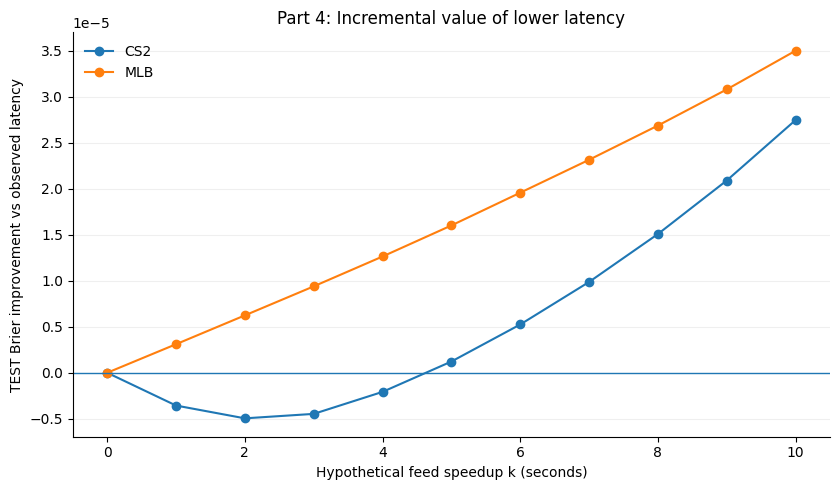

In [21]:

part4_speed_value = pd.concat([
    cs2_dense_test_curve.assign(sport="CS2"),
    mlb_dense_test_curve.assign(sport="MLB")
], ignore_index=True)

display(
    part4_speed_value[
        ["sport", "k", "train_weight", "blend_brier",
         "improvement_vs_k0", "improvement_vs_tape", "n"]
    ]
)

fig, ax = plt.subplots(figsize=(8.5, 5))
for sport, g in part4_speed_value.groupby("sport"):
    ax.plot(g["k"], g["improvement_vs_k0"], marker="o", label=sport)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Hypothetical feed speedup k (seconds)")
ax.set_ylabel("TEST Brier improvement vs observed latency")
ax.set_title("Part 4: Incremental value of lower latency")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


# Part 5 — Predict short-horizon market moves

Targets are future **book-mid changes** at +10 s and +30 s. Predictors are causal tape/feed state. Models are tuned with match-grouped cross-validation on TRAIN and evaluated once on TEST.


### 5.1 Targets and causal features

In [22]:
# Book-mid targets

# IMPORTANT: Part 5 uses the raw sport BBO, matching the original analysis.
# We enforce causality with backward as-of matching and a 3-second freshness cap.
# book_quality filtering is reserved for the Part 6 queue simulation.

def make_book_signal(sport):
    x = bbo[
        bbo["sport"].astype(str).str.upper() == sport.upper()
    ].copy()

    x["book_mid"] = (
        x["bid"].astype(float)
        + x["ask"].astype(float)
    ) / 2

    return (
        x[["match_id", "t_ns", "book_mid"]]
        .sort_values(["match_id", "t_ns"])
        .reset_index(drop=True)
    )


def add_book_targets(
    grid,
    book,
    horizons=(10, 30),
    max_age_s=3
):
    out = grid.copy().reset_index(drop=True)

    right = (
        book[["match_id", "t_ns", "book_mid"]]
        .dropna(subset=["t_ns", "book_mid"])
        .drop_duplicates(["match_id", "t_ns"])
        .copy()
    )

    for h in [0] + list(horizons):
        q = out[["match_id", "t_eval_ns"]].copy()
        q["_i"] = np.arange(len(q))
        q["query_t_ns"] = q["t_eval_ns"] + int(h * 1e9)

        m = pd.merge_asof(
            q.sort_values(["query_t_ns", "match_id"]),
            right.sort_values(["t_ns", "match_id"]),
            left_on="query_t_ns",
            right_on="t_ns",
            by="match_id",
            direction="backward"
        )

        m = m.sort_values("_i").reset_index(drop=True)
        age_s = (m["query_t_ns"] - m["t_ns"]) / 1e9

        valid = (
            m["book_mid"].notna()
            & age_s.between(0, max_age_s, inclusive="both")
        )

        out[f"book_mid_{h}"] = np.where(
            valid,
            m["book_mid"],
            np.nan
        )

    for h in horizons:
        out[f"y_{h}"] = (
            out[f"book_mid_{h}"]
            - out["book_mid_0"]
        )

    return out


def target_summary(name, df):
    print(f"\n{name}")

    for h in [10, 30]:
        valid = df[f"y_{h}"].notna()

        print(
            f"{h}s:",
            f"{valid.sum():,} rows,",
            f"{df.loc[valid, 'match_id'].nunique()} matches,",
            f"mean={df.loc[valid, f'y_{h}'].mean():.6f},",
            f"sd={df.loc[valid, f'y_{h}'].std():.6f}"
        )


cs2_book_p5 = make_book_signal("CS2")
mlb_book_p5 = make_book_signal("MLB")

cs2_p5_train = add_book_targets(cs2_train_grid, cs2_book_p5)
cs2_p5_test = add_book_targets(cs2_test_grid, cs2_book_p5)
mlb_p5_train = add_book_targets(mlb_train_grid, mlb_book_p5)
mlb_p5_test = add_book_targets(mlb_test_grid, mlb_book_p5)

target_summary("CS2 TRAIN", cs2_p5_train)
target_summary("CS2 TEST", cs2_p5_test)
target_summary("MLB TRAIN", mlb_p5_train)
target_summary("MLB TEST", mlb_p5_test)



CS2 TRAIN
10s: 175,704 rows, 59 matches, mean=-0.000140, sd=0.019696
30s: 168,702 rows, 58 matches, mean=-0.000599, sd=0.034508

CS2 TEST
10s: 88,696 rows, 25 matches, mean=-0.000057, sd=0.017496
30s: 84,456 rows, 25 matches, mean=-0.000197, sd=0.030748

MLB TRAIN
10s: 428,063 rows, 63 matches, mean=0.000039, sd=0.016760
30s: 423,473 rows, 63 matches, mean=0.000122, sd=0.029786

MLB TEST
10s: 269,153 rows, 31 matches, mean=-0.000061, sd=0.016792
30s: 267,923 rows, 31 matches, mean=-0.000182, sd=0.030242


In [23]:
# Tape and market-state features


def add_trade_features(
    grid,
    trades_df,
    safety_s=0.10
):
    pieces = []

    for match_id, g in grid.groupby(
        "match_id",
        sort=False
    ):
        out = g.copy().reset_index(drop=True)

        tr = (
            trades_df[
                trades_df["match_id"] == match_id
            ]
            .sort_values("t_ns")
            .copy()
        )

        for h in [1, 5, 15]:
            out[f"signed_vol_{h}s"] = 0.0

        out["print_intensity_5s"] = 0.0
        out["time_in_game_s"] = np.nan

        if len(tr) > 0:
            tt = tr["t_ns"].to_numpy(np.int64)

            size = (
                tr["count"].to_numpy(float)
                if "count" in tr.columns
                else np.ones(len(tr))
            )

            signed = (
                tr["dir"].to_numpy(float)
                * size
            )

            cum_signed = np.concatenate([
                [0.0],
                np.cumsum(signed)
            ])

            cum_count = np.arange(
                len(tr) + 1,
                dtype=float
            )

            eval_t = (
                out["t_eval_ns"].to_numpy(np.int64)
                - int(safety_s * 1e9)
            )

            right = np.searchsorted(
                tt,
                eval_t,
                side="right"
            )

            for h in [1, 5, 15]:
                left_t = (
                    eval_t
                    - int(h * 1e9)
                )

                left = np.searchsorted(
                    tt,
                    left_t,
                    side="right"
                )

                out[f"signed_vol_{h}s"] = (
                    cum_signed[right]
                    - cum_signed[left]
                )

            left5 = np.searchsorted(
                tt,
                eval_t - int(5e9),
                side="right"
            )

            out["print_intensity_5s"] = (
                cum_count[right]
                - cum_count[left5]
            ) / 5.0

            out["time_in_game_s"] = (
                out["t_eval_ns"].to_numpy(np.int64)
                - tt.min()
            ) / 1e9

        out["dist_boundary"] = np.minimum(
            out["tape_mid"],
            1 - out["tape_mid"]
        )

        pieces.append(out)

    return pd.concat(
        pieces,
        ignore_index=True
    )


cs2_p5_train = add_trade_features(
    cs2_p5_train,
    cs2_inplay
)

cs2_p5_test = add_trade_features(
    cs2_p5_test,
    cs2_inplay
)

mlb_p5_train = add_trade_features(
    mlb_p5_train,
    mlb_inplay
)

mlb_p5_test = add_trade_features(
    mlb_p5_test,
    mlb_inplay
)


trade_features = [
    "signed_vol_1s",
    "signed_vol_5s",
    "signed_vol_15s",
    "print_intensity_5s",
    "dist_boundary",
    "time_in_game_s"
]

display(
    cs2_p5_train[
        trade_features
    ].describe().T
)

display(
    mlb_p5_train[
        trade_features
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
signed_vol_1s,793722.0,0.116077,105.787804,-14419.480000,0.000000,0.000000,0.000000,10521.500000
signed_vol_5s,793722.0,0.563726,243.983276,-14449.480000,0.000000,0.000000,0.000000,10521.500000
signed_vol_15s,793722.0,1.583972,436.861841,-14449.480000,0.000000,0.000000,1.000000,13340.720000
print_intensity_5s,793722.0,0.288576,0.863956,0.000000,0.000000,0.000000,0.200000,32.400000
dist_boundary,793722.0,0.295409,0.128266,0.000000,0.190000,0.310000,0.400000,0.500000
time_in_game_s,793722.0,4687.378944,2910.413597,1.803927,2330.216868,4351.258778,6623.268177,15090.399034


,count,mean,std,min,25%,50%,75%,max
signed_vol_1s,594723.0,-8.649251,1726.970769,-210786.050000,0.000000,0.000000,0.000000,216376.310000
signed_vol_5s,594723.0,-42.923691,4032.510942,-226181.500000,-138.035000,0.000000,93.760000,216462.310000
signed_vol_15s,594723.0,-126.537721,7334.364576,-237054.600000,-636.730000,-11.500000,475.190000,380526.670000
print_intensity_5s,594723.0,1.325969,2.604893,0.000000,0.200000,0.600000,1.400000,130.400000
dist_boundary,594723.0,0.224611,0.165503,0.005000,0.065000,0.195000,0.385000,0.495000
time_in_game_s,594723.0,4844.200375,2884.552748,1.437942,2372.728914,4732.733467,7224.220312,12011.872043


In [24]:
# External-feed features


mlb_feed_p5 = mlb_states_p4.copy()

complete = (
    mlb_feed_p5[feature_cols]
    .notna()
    .all(axis=1)
)

mlb_feed_p5["feed_prob"] = np.nan

mlb_feed_p5.loc[
    complete,
    "feed_prob"
] = mlb_wp_model.predict_proba(
    mlb_feed_p5.loc[
        complete,
        feature_cols
    ]
)[:, 1]

mlb_feed_p5 = (
    mlb_feed_p5[
        ["match_id", "t_recv_ns", "feed_prob"]
    ]
    .dropna()
    .sort_values(
        ["match_id", "t_recv_ns"]
    )
    .reset_index(drop=True)
)


cs2_feed_p5 = (
    beter_for_p4[
        ["match_id", "t_recv_ns", "p1"]
    ]
    .dropna()
    .rename(
        columns={"p1": "feed_prob"}
    )
    .sort_values(
        ["match_id", "t_recv_ns"]
    )
    .reset_index(drop=True)
)


def make_feed_jumps(feed):
    x = feed.copy()

    x["prev_feed_prob"] = (
        x.groupby("match_id")[
            "feed_prob"
        ]
        .shift(1)
    )

    x["feed_jump"] = (
        x["feed_prob"]
        - x["prev_feed_prob"]
    )

    x["feed_jump_abs"] = (
        x["feed_jump"].abs()
    )

    x["event_t_ns"] = x["t_recv_ns"]

    jumps = x[
        x["feed_jump"].notna()
        & (x["feed_jump"] != 0)
    ].copy()

    jumps["jump_t_ns"] = (
        jumps["t_recv_ns"]
    )

    return x, jumps


cs2_feed_events, cs2_feed_jumps = (
    make_feed_jumps(cs2_feed_p5)
)

mlb_feed_events, mlb_feed_jumps = (
    make_feed_jumps(mlb_feed_p5)
)


print(
    "CS2 feed messages:",
    len(cs2_feed_events),
    "| actual probability jumps:",
    len(cs2_feed_jumps)
)

print(
    "MLB state messages:",
    len(mlb_feed_events),
    "| actual probability jumps:",
    len(mlb_feed_jumps)
)


def add_feed_features(
    grid,
    feed_events,
    feed_jumps,
    shift_s=0
):
    out = grid.copy().reset_index(drop=True)

    current = starter.asof(
        left=out,
        right=feed_events,
        left_t="t_eval_ns",
        right_t="t_recv_ns",
        by="match_id",
        shift_s=shift_s,
        cols=[
            "feed_prob",
            "event_t_ns"
        ]
    ).reset_index(drop=True)

    jump = starter.asof(
        left=out,
        right=feed_jumps,
        left_t="t_eval_ns",
        right_t="t_recv_ns",
        by="match_id",
        shift_s=shift_s,
        cols=[
            "feed_jump",
            "feed_jump_abs",
            "jump_t_ns"
        ]
    ).reset_index(drop=True)

    out["feed_prob"] = (
        current["feed_prob"]
        .to_numpy()
    )

    out["feed_minus_mid"] = (
        out["feed_prob"]
        - out["tape_mid"]
    )

    out["last_feed_jump"] = (
        jump["feed_jump"]
        .to_numpy()
    )

    out["last_feed_jump_abs"] = (
        jump["feed_jump_abs"]
        .to_numpy()
    )

    effective_t = (
        out["t_eval_ns"].to_numpy(np.int64)
        + int(shift_s * 1e9)
    )

    out["feed_event_age_s"] = (
        effective_t
        - current["event_t_ns"]
        .to_numpy(float)
    ) / 1e9

    out["feed_jump_age_s"] = (
        effective_t
        - jump["jump_t_ns"]
        .to_numpy(float)
    ) / 1e9

    return out


cs2_p5_train_arrived = add_feed_features(
    cs2_p5_train,
    cs2_feed_events,
    cs2_feed_jumps,
    shift_s=0
)

cs2_p5_test_arrived = add_feed_features(
    cs2_p5_test,
    cs2_feed_events,
    cs2_feed_jumps,
    shift_s=0
)

mlb_p5_train_arrived = add_feed_features(
    mlb_p5_train,
    mlb_feed_events,
    mlb_feed_jumps,
    shift_s=0
)

mlb_p5_test_arrived = add_feed_features(
    mlb_p5_test,
    mlb_feed_events,
    mlb_feed_jumps,
    shift_s=0
)


CS2_K = float(part4_parity.loc[part4_parity["feature"].eq("CS2 match-winner"), "k_needed_exact_s"].iloc[0])
MLB_K = 0.0


cs2_p5_train_fast = add_feed_features(
    cs2_p5_train,
    cs2_feed_events,
    cs2_feed_jumps,
    shift_s=CS2_K
)

cs2_p5_test_fast = add_feed_features(
    cs2_p5_test,
    cs2_feed_events,
    cs2_feed_jumps,
    shift_s=CS2_K
)

mlb_p5_train_fast = add_feed_features(
    mlb_p5_train,
    mlb_feed_events,
    mlb_feed_jumps,
    shift_s=MLB_K
)

mlb_p5_test_fast = add_feed_features(
    mlb_p5_test,
    mlb_feed_events,
    mlb_feed_jumps,
    shift_s=MLB_K
)


C:\Users\ishan\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


CS2 feed messages: 57782 | actual probability jumps: 57315
MLB state messages: 27836 | actual probability jumps: 8839


### 5.2 Directional Ridge models

In [25]:
# Prepare and fit directional models


def prepare_p5_model(df):
    x = df.copy()

    x["tape_mid_centered"] = (
        x["tape_mid"] - 0.5
    )

    x["feed_jump_age_log"] = np.log1p(
        x["feed_jump_age_s"].clip(
            lower=0,
            upper=300
        )
    )

    x["feed_event_age_log"] = np.log1p(
        x["feed_event_age_s"].clip(
            lower=0,
            upper=300
        )
    )

    x["print_intensity_log"] = np.log1p(
        x["print_intensity_5s"].clip(lower=0)
    )

    x["time_in_game_hr"] = (
        x["time_in_game_s"] / 3600
    )

    return x


cs2_train_a = prepare_p5_model(
    cs2_p5_train_arrived
)
cs2_test_a = prepare_p5_model(
    cs2_p5_test_arrived
)

cs2_train_f = prepare_p5_model(
    cs2_p5_train_fast
)
cs2_test_f = prepare_p5_model(
    cs2_p5_test_fast
)

mlb_train_a = prepare_p5_model(
    mlb_p5_train_arrived
)
mlb_test_a = prepare_p5_model(
    mlb_p5_test_arrived
)

mlb_train_f = prepare_p5_model(
    mlb_p5_train_fast
)
mlb_test_f = prepare_p5_model(
    mlb_p5_test_fast
)


p5_features = [
    "tape_mid_centered",
    "feed_minus_mid",
    "last_feed_jump",
    "last_feed_jump_abs",
    "feed_jump_age_log",
    "feed_event_age_log",
    "signed_vol_1s",
    "signed_vol_5s",
    "signed_vol_15s",
    "print_intensity_log",
    "dist_boundary",
    "time_in_game_hr"
]


from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score


def fit_p5_ridge(
    train,
    test,
    horizon,
    features=p5_features
):
    target = f"y_{horizon}"

    cols = (
        ["match_id"]
        + features
        + [target]
    )

    tr = train[cols].dropna().copy()
    te = test[cols].dropna().copy()

    Xtr = tr[features]
    ytr = tr[target]

    Xte = te[features]
    yte = te[target]

    groups = tr["match_id"]

    alphas = [
    0.1,
    1,
    10,
    100,
    1000,
    10000
    ]

    gkf = GroupKFold(n_splits=3)

    cv_results = []

    for alpha in alphas:
        fold_mse = []

        for train_idx, val_idx in gkf.split(
            Xtr,
            ytr,
            groups
        ):
            model = Pipeline([
                ("scale", StandardScaler()),
                ("ridge", Ridge(alpha=alpha))
            ])

            model.fit(
                Xtr.iloc[train_idx],
                ytr.iloc[train_idx]
            )

            pred = model.predict(
                Xtr.iloc[val_idx]
            )

            fold_mse.append(
                mean_squared_error(
                    ytr.iloc[val_idx],
                    pred
                )
            )

        cv_results.append({
            "alpha": alpha,
            "cv_mse": np.mean(fold_mse)
        })

    cv_results = pd.DataFrame(cv_results)

    best_alpha = (
        cv_results
        .sort_values("cv_mse")
        .iloc[0]["alpha"]
    )

    model = Pipeline([
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=best_alpha))
    ])

    model.fit(Xtr, ytr)

    pred = model.predict(Xte)

    result = {
        "model": model,
        "alpha": best_alpha,
        "n_train": len(tr),
        "n_test": len(te),
        "matches_test": te["match_id"].nunique(),
        "r2": r2_score(yte, pred),
        "rmse": np.sqrt(
            mean_squared_error(yte, pred)
        ),
        "test_df": te.assign(pred=pred),
        "cv": cv_results
    }

    return result


datasets = {
    ("CS2", "arrived"): (
        cs2_train_a,
        cs2_test_a
    ),
    ("CS2", "faster"): (
        cs2_train_f,
        cs2_test_f
    ),
    ("MLB", "arrived"): (
        mlb_train_a,
        mlb_test_a
    ),
    ("MLB", "faster"): (
        mlb_train_f,
        mlb_test_f
    )
}

p5_models = {}

rows = []

for (sport, version), (
    train_df,
    test_df
) in datasets.items():

    for h in [10, 30]:

        result = fit_p5_ridge(
            train_df,
            test_df,
            horizon=h
        )

        p5_models[
            (sport, version, h)
        ] = result

        rows.append({
            "sport": sport,
            "feed": version,
            "horizon_s": h,
            "alpha": result["alpha"],
            "n_test": result["n_test"],
            "matches": result["matches_test"],
            "test_r2": result["r2"],
            "test_rmse": result["rmse"]
        })

p5_results = pd.DataFrame(rows)

display(
    p5_results.sort_values(
        ["sport", "horizon_s", "feed"]
    )
)


importance_rows = []

for (
    sport,
    version,
    h
), result in p5_models.items():

    coef = (
        result["model"]
        .named_steps["ridge"]
        .coef_
    )

    for feature, value in zip(
        p5_features,
        coef
    ):
        importance_rows.append({
            "sport": sport,
            "feed": version,
            "horizon_s": h,
            "feature": feature,
            "coef": value,
            "abs_coef": abs(value)
        })

p5_importance = pd.DataFrame(
    importance_rows
)

for sport in ["CS2", "MLB"]:
    for h in [10, 30]:
        print(
            f"\n{sport} — {h}s — arrived feed"
        )

        display(
            p5_importance[
                (p5_importance["sport"] == sport)
                & (p5_importance["feed"] == "arrived")
                & (p5_importance["horizon_s"] == h)
            ]
            .sort_values(
                "abs_coef",
                ascending=False
            )
            .head(8)
        )


display(
    p5_results.sort_values(
        ["sport", "horizon_s", "feed"]
    )
)


,sport,feed,horizon_s,alpha,n_test,matches,test_r2,test_rmse
0,CS2,arrived,10,10000.0,88292,25,0.003616,0.017491
2,CS2,faster,10,10000.0,88293,25,0.003668,0.017490
1,CS2,arrived,30,10000.0,84095,25,0.004577,0.030734
3,CS2,faster,30,10000.0,84096,25,0.004578,0.030734
4,MLB,arrived,10,10000.0,267075,31,0.000337,0.016832
6,MLB,faster,10,10000.0,267075,31,0.000337,0.016832
5,MLB,arrived,30,10000.0,265850,31,-0.000396,0.030332
7,MLB,faster,30,10000.0,265850,31,-0.000396,0.030332



CS2 — 10s — arrived feed


,sport,feed,horizon_s,feature,coef,abs_coef
1,CS2,arrived,10,feed_minus_mid,0.002026,0.002026
2,CS2,arrived,10,last_feed_jump,0.000996,0.000996
6,CS2,arrived,10,signed_vol_1s,0.000493,0.000493
5,CS2,arrived,10,feed_event_age_log,0.000261,0.000261
3,CS2,arrived,10,last_feed_jump_abs,-0.000200,0.000200
10,CS2,arrived,10,dist_boundary,0.000198,0.000198
7,CS2,arrived,10,signed_vol_5s,0.000186,0.000186
8,CS2,arrived,10,signed_vol_15s,0.000101,0.000101



CS2 — 30s — arrived feed


,sport,feed,horizon_s,feature,coef,abs_coef
13,CS2,arrived,30,feed_minus_mid,0.004428,0.004428
14,CS2,arrived,30,last_feed_jump,0.001420,0.001420
17,CS2,arrived,30,feed_event_age_log,0.000503,0.000503
18,CS2,arrived,30,signed_vol_1s,0.000496,0.000496
22,CS2,arrived,30,dist_boundary,0.000442,0.000442
20,CS2,arrived,30,signed_vol_15s,0.000391,0.000391
21,CS2,arrived,30,print_intensity_log,0.000280,0.000280
15,CS2,arrived,30,last_feed_jump_abs,-0.000256,0.000256



MLB — 10s — arrived feed


,sport,feed,horizon_s,feature,coef,abs_coef
55,MLB,arrived,10,signed_vol_5s,0.000299,0.000299
54,MLB,arrived,10,signed_vol_1s,0.000244,0.000244
49,MLB,arrived,10,feed_minus_mid,-0.000173,0.000173
50,MLB,arrived,10,last_feed_jump,0.000120,0.000120
56,MLB,arrived,10,signed_vol_15s,0.000092,0.000092
57,MLB,arrived,10,print_intensity_log,0.000066,0.000066
59,MLB,arrived,10,time_in_game_hr,-0.000060,0.000060
53,MLB,arrived,10,feed_event_age_log,0.000051,0.000051



MLB — 30s — arrived feed


,sport,feed,horizon_s,feature,coef,abs_coef
62,MLB,arrived,30,last_feed_jump,0.000375,0.000375
67,MLB,arrived,30,signed_vol_5s,0.000341,0.000341
71,MLB,arrived,30,time_in_game_hr,-0.000262,0.000262
66,MLB,arrived,30,signed_vol_1s,0.000246,0.000246
70,MLB,arrived,30,dist_boundary,-0.000219,0.000219
65,MLB,arrived,30,feed_event_age_log,0.000177,0.000177
69,MLB,arrived,30,print_intensity_log,0.000137,0.000137
63,MLB,arrived,30,last_feed_jump_abs,0.000131,0.000131


,sport,feed,horizon_s,alpha,n_test,matches,test_r2,test_rmse
0,CS2,arrived,10,10000.0,88292,25,0.003616,0.017491
2,CS2,faster,10,10000.0,88293,25,0.003668,0.017490
1,CS2,arrived,30,10000.0,84095,25,0.004577,0.030734
3,CS2,faster,30,10000.0,84096,25,0.004578,0.030734
4,MLB,arrived,10,10000.0,267075,31,0.000337,0.016832
6,MLB,faster,10,10000.0,267075,31,0.000337,0.016832
5,MLB,arrived,30,10000.0,265850,31,-0.000396,0.030332
7,MLB,faster,30,10000.0,265850,31,-0.000396,0.030332


### 5.3 MLB hazard model

In [26]:
# Hazard model and TRAIN-only threshold


sr_delta = sr[
    sr["feedtype"].astype(str).str.lower().eq("delta")
].copy()

sr_delta["type_num"] = pd.to_numeric(
    sr_delta["type"],
    errors="coerce"
)

sr_delta["betstop_subtype"] = (
    sr_delta["info"]
    .astype(str)
    .str.replace(
        r"^Betstop\s*-\s*",
        "",
        regex=True
    )
    .str.strip()
)


event_tables = {
    "pitch_release": sr_delta[
        sr_delta["type_num"] == 2327
    ].copy(),

    "ball_in_play": sr_delta[
        sr_delta["type_num"] == 1031
    ].copy(),

    "possible_run": sr_delta[
        (sr_delta["type_num"] == 1011)
        & (
            sr_delta["betstop_subtype"]
            .str.lower()
            .eq("possible run")
        )
    ].copy(),

    "deep_ball": sr_delta[
        (sr_delta["type_num"] == 1011)
        & (
            sr_delta["betstop_subtype"]
            .str.lower()
            .eq("deep ball")
        )
    ].copy()
}

for name, x in event_tables.items():
    x["event_time_ns"] = x["t_recv_ns"]
    event_tables[name] = (
        x[
            ["match_id", "t_recv_ns", "event_time_ns"]
        ]
        .sort_values(["match_id", "t_recv_ns"])
        .reset_index(drop=True)
    )


def add_mlb_hazard_events(df):
    out = df.copy().reset_index(drop=True)

    for name, events in event_tables.items():

        matched = starter.asof(
            left=out,
            right=events,
            left_t="t_eval_ns",
            right_t="t_recv_ns",
            by="match_id",
            shift_s=0,
            cols=["event_time_ns"]
        ).reset_index(drop=True)

        age = (
            out["t_eval_ns"].to_numpy(float)
            - matched["event_time_ns"].to_numpy(float)
        ) / 1e9

        out[f"{name}_age_s"] = age

        out[f"recent_{name}_5s"] = (
            (age >= 0)
            & (age <= 5)
        ).astype(int)

    return out


mlb_hazard_train = add_mlb_hazard_events(
    mlb_train_a
)

mlb_hazard_test = add_mlb_hazard_events(
    mlb_test_a
)


def prepare_hazard_features(df):
    x = df.copy()

    x["jump_10"] = (
        x["y_10"].abs() > 0.02
    ).astype(int)

    x["abs_feed_minus_mid"] = (
        x["feed_minus_mid"].abs()
    )

    x["abs_signed_vol_1s"] = (
        x["signed_vol_1s"].abs()
    )

    x["abs_signed_vol_5s"] = (
        x["signed_vol_5s"].abs()
    )

    x["abs_signed_vol_15s"] = (
        x["signed_vol_15s"].abs()
    )

    return x


mlb_hazard_train = prepare_hazard_features(
    mlb_hazard_train
)

mlb_hazard_test = prepare_hazard_features(
    mlb_hazard_test
)


hazard_features = [
    "recent_pitch_release_5s",
    "recent_ball_in_play_5s",
    "recent_possible_run_5s",
    "recent_deep_ball_5s",
    "abs_feed_minus_mid",
    "last_feed_jump_abs",
    "abs_signed_vol_1s",
    "abs_signed_vol_5s",
    "abs_signed_vol_15s",
    "print_intensity_log",
    "dist_boundary",
    "time_in_game_hr"
]


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss
)


def fit_hazard_model(train, test):
    cols = (
        ["match_id"]
        + hazard_features
        + ["jump_10"]
    )

    tr = train[cols].dropna().copy()
    te = test[cols].dropna().copy()

    Xtr = tr[hazard_features]
    ytr = tr["jump_10"]

    Xte = te[hazard_features]
    yte = te["jump_10"]

    groups = tr["match_id"]

    Cs = [
        0.01,
        0.1,
        1,
        10
    ]

    gkf = GroupKFold(n_splits=3)

    rows = []

    for C in Cs:
        scores = []

        for ti, vi in gkf.split(
            Xtr,
            ytr,
            groups
        ):
            model = Pipeline([
                ("scale", StandardScaler()),
                (
                    "logit",
                    LogisticRegression(
                        C=C,
                        max_iter=1000
                    )
                )
            ])

            model.fit(
                Xtr.iloc[ti],
                ytr.iloc[ti]
            )

            prob = model.predict_proba(
                Xtr.iloc[vi]
            )[:, 1]

            scores.append(
                brier_score_loss(
                    ytr.iloc[vi],
                    prob
                )
            )

        rows.append({
            "C": C,
            "cv_brier": np.mean(scores)
        })

    cv = pd.DataFrame(rows)

    best_C = (
        cv.sort_values("cv_brier")
        .iloc[0]["C"]
    )

    model = Pipeline([
        ("scale", StandardScaler()),
        (
            "logit",
            LogisticRegression(
                C=best_C,
                max_iter=1000
            )
        )
    ])

    model.fit(Xtr, ytr)

    prob = model.predict_proba(Xte)[:, 1]

    te = te.copy()
    te["hazard_prob"] = prob

    return {
        "model": model,
        "best_C": best_C,
        "test": te,
        "auc": roc_auc_score(yte, prob),
        "brier": brier_score_loss(yte, prob),
        "baseline_jump_rate": yte.mean()
    }


mlb_hazard = fit_hazard_model(
    mlb_hazard_train,
    mlb_hazard_test
)


print(
    "Best C:",
    mlb_hazard["best_C"]
)

print(
    "TEST AUC:",
    mlb_hazard["auc"]
)

print(
    "TEST Brier:",
    mlb_hazard["brier"]
)

print(
    "TEST >2c baseline rate:",
    mlb_hazard["baseline_jump_rate"]
)


hazard_test = mlb_hazard["test"].copy()

hazard_test["hazard_decile"] = pd.qcut(
    hazard_test["hazard_prob"],
    10,
    labels=False,
    duplicates="drop"
)

hazard_deciles = (
    hazard_test
    .groupby("hazard_decile")
    .agg(
        n=("jump_10", "size"),
        predicted_risk=("hazard_prob", "mean"),
        actual_jump_rate=("jump_10", "mean")
    )
    .reset_index()
)

display(hazard_deciles)


hazard_coef = pd.DataFrame({
    "feature": hazard_features,
    "coef": (
        mlb_hazard["model"]
        .named_steps["logit"]
        .coef_[0]
    )
})

hazard_coef["abs_coef"] = (
    hazard_coef["coef"].abs()
)

display(
    hazard_coef.sort_values(
        "abs_coef",
        ascending=False
    )
)


from sklearn.model_selection import GroupKFold

tr = mlb_hazard_train[
    ["match_id"] + hazard_features + ["jump_10"]
].dropna().copy()

X = tr[hazard_features]
y = tr["jump_10"]
groups = tr["match_id"]

oof_prob = np.full(len(tr), np.nan)

gkf = GroupKFold(n_splits=3)

for ti, vi in gkf.split(X, y, groups):
    model = Pipeline([
        ("scale", StandardScaler()),
        (
            "logit",
            LogisticRegression(
                C=mlb_hazard["best_C"],
                max_iter=1000
            )
        )
    ])

    model.fit(
        X.iloc[ti],
        y.iloc[ti]
    )

    oof_prob[vi] = model.predict_proba(
        X.iloc[vi]
    )[:, 1]

tr["hazard_oof"] = oof_prob


cancel_rows = []

for cancel_share in [0.05, 0.10, 0.20, 0.30]:

    threshold = tr["hazard_oof"].quantile(
        1 - cancel_share
    )

    cancel = tr["hazard_oof"] >= threshold
    keep = ~cancel

    cancel_rows.append({
        "cancel_share": cancel.mean(),
        "threshold": threshold,
        "jump_rate_cancelled": tr.loc[
            cancel, "jump_10"
        ].mean(),
        "jump_rate_kept": tr.loc[
            keep, "jump_10"
        ].mean(),
        "share_of_all_jumps_removed": (
            tr.loc[cancel, "jump_10"].sum()
            / tr["jump_10"].sum()
        )
    })

cancel_tradeoff = pd.DataFrame(cancel_rows)

display(cancel_tradeoff)


hazard_threshold = float(
    cancel_tradeoff.loc[
        np.isclose(cancel_tradeoff["cancel_share"], 0.10),
        "threshold"
    ].iloc[0]
)

hazard_test = mlb_hazard["test"].copy()

hazard_test["cancel"] = (
    hazard_test["hazard_prob"]
    >= hazard_threshold
)

cancel = hazard_test["cancel"]
keep = ~cancel

hazard_test_summary = pd.DataFrame([{
    "cancel_share": cancel.mean(),

    "jump_rate_cancelled": hazard_test.loc[
        cancel, "jump_10"
    ].mean(),

    "jump_rate_kept": hazard_test.loc[
        keep, "jump_10"
    ].mean(),

    "share_of_all_jumps_removed": (
        hazard_test.loc[
            cancel, "jump_10"
        ].sum()
        / hazard_test["jump_10"].sum()
    ),

    "baseline_jump_rate": (
        hazard_test["jump_10"].mean()
    )
}])

display(hazard_test_summary)


hazard_test_summary[
    "risk_ratio_cancel_vs_keep"
] = (
    hazard_test_summary["jump_rate_cancelled"]
    / hazard_test_summary["jump_rate_kept"]
)

display(hazard_test_summary)


Best C: 0.01
TEST AUC: 0.7515369775891025
TEST Brier: 0.049511898745418524
TEST >2c baseline rate: 0.05728519235987102


,hazard_decile,n,predicted_risk,actual_jump_rate
0,0,31696,0.011230,0.003849
1,1,31696,0.016522,0.012715
2,2,31696,0.021989,0.025902
3,3,31695,0.027769,0.033980
4,4,31696,0.034374,0.038712
5,5,31696,0.042827,0.045589
6,6,31695,0.054672,0.054015
7,7,31696,0.072185,0.059818
8,8,31696,0.106187,0.081998
9,9,31696,0.292233,0.216273


,feature,coef,abs_coef
10,dist_boundary,0.646439,0.646439
9,print_intensity_log,0.382937,0.382937
1,recent_ball_in_play_5s,0.287198,0.287198
11,time_in_game_hr,0.243882,0.243882
0,recent_pitch_release_5s,0.208073,0.208073
7,abs_signed_vol_5s,-0.102327,0.102327
5,last_feed_jump_abs,0.096006,0.096006
4,abs_feed_minus_mid,0.088336,0.088336
2,recent_possible_run_5s,0.040906,0.040906
6,abs_signed_vol_1s,0.033327,0.033327


,cancel_share,threshold,jump_rate_cancelled,jump_rate_kept,share_of_all_jumps_removed
0,0.050000,0.131777,0.276518,0.036030,0.287715
1,0.100000,0.088532,0.190040,0.032278,0.395471
2,0.200001,0.059844,0.131030,0.027310,0.545342
3,0.300001,0.046318,0.104416,0.023899,0.651864


,cancel_share,jump_rate_cancelled,jump_rate_kept,share_of_all_jumps_removed,baseline_jump_rate
0,0.186763,0.15447,0.034966,0.503607,0.057285


,cancel_share,jump_rate_cancelled,jump_rate_kept,share_of_all_jumps_removed,baseline_jump_rate,risk_ratio_cancel_vs_keep
0,0.186763,0.15447,0.034966,0.503607,0.057285,4.417671


### 5.4 Required TAKE and CANCEL rules

In [27]:
# Directional forecasts, TAKE, and CANCEL evaluation


def directional_oof(train, horizon, alpha):
    target = f"y_{horizon}"

    cols = (
        ["match_id", "t_eval_ns", "book_mid_0"]
        + p5_features
        + [target]
    )

    tr = train[cols].dropna().copy().reset_index(drop=True)

    X = tr[p5_features]
    y = tr[target]
    groups = tr["match_id"]

    pred = np.full(len(tr), np.nan)

    gkf = GroupKFold(n_splits=3)

    for ti, vi in gkf.split(X, y, groups):

        model = Pipeline([
            ("scale", StandardScaler()),
            ("ridge", Ridge(alpha=alpha))
        ])

        model.fit(
            X.iloc[ti],
            y.iloc[ti]
        )

        pred[vi] = model.predict(
            X.iloc[vi]
        )

    tr["pred"] = pred

    return tr


cs2_alpha_10 = p5_models[
    ("CS2", "arrived", 10)
]["alpha"]

mlb_alpha_10 = p5_models[
    ("MLB", "arrived", 10)
]["alpha"]

cs2_oof = directional_oof(
    cs2_train_a,
    10,
    cs2_alpha_10
)

mlb_oof = directional_oof(
    mlb_train_a,
    10,
    mlb_alpha_10
)

CS2_CANCEL_X = (
    cs2_oof["pred"].abs().quantile(0.90)
)

MLB_CANCEL_X = (
    mlb_oof["pred"].abs().quantile(0.90)
)

print("CS2 cancel x:", CS2_CANCEL_X)
print("MLB cancel x:", MLB_CANCEL_X)


def predict_p5_full(
    df,
    result,
    horizon
):
    target = f"y_{horizon}"

    valid = (
        df[p5_features + [target]]
        .notna()
        .all(axis=1)
    )

    out = df.loc[valid].copy()

    out["pred"] = (
        result["model"]
        .predict(out[p5_features])
    )

    return out


cs2_test_pred = predict_p5_full(
    cs2_test_a,
    p5_models[("CS2", "arrived", 10)],
    10
)

mlb_test_pred = predict_p5_full(
    mlb_test_a,
    p5_models[("MLB", "arrived", 10)],
    10
)


def prepare_touch(book):
    x = book.copy()

    if "book_ok" in x.columns:
        x = x[
            x["book_ok"]
            .fillna(False)
        ].copy()

    return (
        x[
            [
                "match_id",
                "t_ns",
                "bid",
                "ask"
            ]
        ]
        .dropna()
        .sort_values(
            ["match_id", "t_ns"]
        )
        .reset_index(drop=True)
    )


cs2_touch = prepare_touch(cs2_book)
mlb_touch = prepare_touch(mlb_book)


def attach_touch(df, touch, max_age_s=3):
    out = df.copy().reset_index(drop=True)

    q = out[
        ["match_id", "t_eval_ns"]
    ].copy()

    q["_i"] = np.arange(len(q))

    m = pd.merge_asof(
        q.sort_values(
            ["t_eval_ns", "match_id"]
        ),
        touch.sort_values(
            ["t_ns", "match_id"]
        ),
        left_on="t_eval_ns",
        right_on="t_ns",
        by="match_id",
        direction="backward"
    )

    m = (
        m.sort_values("_i")
        .reset_index(drop=True)
    )

    age = (
        m["t_eval_ns"]
        - m["t_ns"]
    ) / 1e9

    valid = age.between(0, max_age_s)

    out["bid"] = np.where(
        valid,
        m["bid"],
        np.nan
    )

    out["ask"] = np.where(
        valid,
        m["ask"],
        np.nan
    )

    return out


cs2_test_pred = attach_touch(
    cs2_test_pred,
    cs2_touch
)

mlb_test_pred = attach_touch(
    mlb_test_pred,
    mlb_touch
)


def evaluate_take(df):
    x = df.dropna(
        subset=[
            "pred",
            "bid",
            "ask",
            "book_mid_0",
            "y_10"
        ]
    ).copy()

    x["halfspread"] = (
        x["ask"] - x["bid"]
    ) / 2

    p = x["book_mid_0"].clip(
        0.001,
        0.999
    )

    x["fee"] = (
        0.07 * p * (1 - p)
    )

    x["take_cost"] = (
        x["halfspread"]
        + x["fee"]
    )

    x["take"] = (
        x["pred"].abs()
        > x["take_cost"]
    )

    x["side"] = np.sign(
        x["pred"]
    )

    x["pnl"] = np.where(
        x["take"],
        x["side"] * x["y_10"]
        - x["take_cost"],
        np.nan
    )

    traded = x[x["take"]].copy()

    return x, traded


cs2_take_all, cs2_take = evaluate_take(
    cs2_test_pred
)

mlb_take_all, mlb_take = evaluate_take(
    mlb_test_pred
)

print(
    "CS2 TAKE:",
    "n =", len(cs2_take),
    "PnL/contract =", cs2_take["pnl"].mean()
)

print(
    "MLB TAKE:",
    "n =", len(mlb_take),
    "PnL/contract =", mlb_take["pnl"].mean()
)


def attach_predictions_to_trades(
    trades_df,
    pred_df
):
    trades_x = trades_df[
        [
            "match_id",
            "t_ns",
            "px",
            "dir"
        ]
    ].copy()

    pred_x = pred_df[
        [
            "match_id",
            "t_eval_ns",
            "pred"
        ]
    ].copy()

    trades_x["_i"] = np.arange(
        len(trades_x)
    )

    m = pd.merge_asof(
        trades_x.sort_values(
            ["t_ns", "match_id"]
        ),
        pred_x.sort_values(
            ["t_eval_ns", "match_id"]
        ),
        left_on="t_ns",
        right_on="t_eval_ns",
        by="match_id",
        direction="backward"
    )

    m = (
        m.sort_values("_i")
        .reset_index(drop=True)
    )

    age = (
        m["t_ns"]
        - m["t_eval_ns"]
    ) / 1e9

    m.loc[
        ~age.between(0, 2),
        "pred"
    ] = np.nan

    return m


cs2_test_ids_p5 = set(
    cs2_test_pred["match_id"]
)

mlb_test_ids_p5 = set(
    mlb_test_pred["match_id"]
)

cs2_trade_eval = attach_predictions_to_trades(
    cs2_inplay[
        cs2_inplay["match_id"]
        .isin(cs2_test_ids_p5)
    ],
    cs2_test_pred
)

mlb_trade_eval = attach_predictions_to_trades(
    mlb_inplay[
        mlb_inplay["match_id"]
        .isin(mlb_test_ids_p5)
    ],
    mlb_test_pred
)


def add_trade_future_mid(
    trades_df,
    book,
    horizon=10,
    max_age_s=3
):
    out = trades_df.copy().reset_index(drop=True)

    out["_row"] = np.arange(len(out))

    q = out[
        ["match_id", "t_ns", "_row"]
    ].copy()

    q["future_t_ns"] = (
        q["t_ns"]
        + int(horizon * 1e9)
    )

    right = (
        book[
            ["match_id", "t_ns", "book_mid"]
        ]
        .dropna(
            subset=["match_id", "t_ns", "book_mid"]
        )
        .drop_duplicates(
            ["match_id", "t_ns"]
        )
        .sort_values(
            ["t_ns", "match_id"]
        )
        .reset_index(drop=True)
    )

    m = pd.merge_asof(
        q.sort_values(
            ["future_t_ns", "match_id"]
        ),
        right,
        left_on="future_t_ns",
        right_on="t_ns",
        by="match_id",
        direction="backward",
        suffixes=("", "_book")
    )

    m = (
        m.sort_values("_row")
        .reset_index(drop=True)
    )

    age = (
        m["future_t_ns"]
        - m["t_ns_book"]
    ) / 1e9

    out["future_mid"] = np.where(
        age.between(
            0,
            max_age_s,
            inclusive="both"
        ),
        m["book_mid"],
        np.nan
    )

    return out.drop(columns="_row")


cs2_trade_eval = add_trade_future_mid(
    cs2_trade_eval,
    cs2_book_p5,
    horizon=10
)

mlb_trade_eval = add_trade_future_mid(
    mlb_trade_eval,
    mlb_book_p5,
    horizon=10
)


def evaluate_cancel(
    trades_df,
    threshold
):
    x = trades_df.dropna(
        subset=[
            "pred",
            "px",
            "dir",
            "future_mid"
        ]
    ).copy()

    x["maker_position"] = (
        -x["dir"]
    )

    x["maker_pnl"] = (
        x["maker_position"]
        * (
            x["future_mid"]
            - x["px"]
        )
    )

    x["cancel"] = (
        ((x["pred"] > threshold) & (x["dir"] > 0))
        |
        ((x["pred"] < -threshold) & (x["dir"] < 0))
    )

    kept = x[~x["cancel"]]
    avoided = x[x["cancel"]]

    return pd.Series({
        "n_candidate_fills": len(x),

        "cancel_share": x["cancel"].mean(),

        "pnl_all": x["maker_pnl"].mean(),

        "pnl_kept": kept["maker_pnl"].mean(),

        "pnl_avoided": avoided["maker_pnl"].mean(),

        "improvement": (
            kept["maker_pnl"].mean()
            - x["maker_pnl"].mean()
        )
    })


cancel_results = pd.DataFrame([
    {
        "sport": "CS2",
        **evaluate_cancel(
            cs2_trade_eval,
            CS2_CANCEL_X
        ).to_dict()
    },

    {
        "sport": "MLB",
        **evaluate_cancel(
            mlb_trade_eval,
            MLB_CANCEL_X
        ).to_dict()
    }
])

display(cancel_results)


def cluster_mean_stats(
    df,
    value_col,
    cluster_col="match_id"
):
    x = df[
        [cluster_col, value_col]
    ].dropna().copy()

    n = len(x)
    G = x[cluster_col].nunique()
    mean = x[value_col].mean()

    x["_resid"] = (
        x[value_col] - mean
    )

    cluster_scores = (
        x.groupby(cluster_col)["_resid"]
        .sum()
    )

    var = (
        (G / (G - 1))
        * np.sum(cluster_scores**2)
        / (n**2)
    )

    se = np.sqrt(var)

    return pd.Series({
        "n": n,
        "matches": G,
        "pnl_per_contract": mean,
        "cluster_se": se,
        "t_stat": mean / se
    })


take_stats = pd.DataFrame([
    {
        "sport": "CS2",
        **cluster_mean_stats(
            cs2_take,
            "pnl"
        ).to_dict()
    },
    {
        "sport": "MLB",
        **cluster_mean_stats(
            mlb_take,
            "pnl"
        ).to_dict()
    }
])

display(take_stats)


def get_cancel_detail(
    trades_df,
    threshold
):
    x = trades_df.dropna(
        subset=[
            "pred",
            "px",
            "dir",
            "future_mid"
        ]
    ).copy()

    x["maker_position"] = -x["dir"]

    x["maker_pnl"] = (
        x["maker_position"]
        * (
            x["future_mid"]
            - x["px"]
        )
    )

    x["cancel"] = (
        ((x["pred"] > threshold) & (x["dir"] > 0))
        |
        ((x["pred"] < -threshold) & (x["dir"] < 0))
    )

    return x


cs2_cancel_detail = get_cancel_detail(
    cs2_trade_eval,
    CS2_CANCEL_X
)

mlb_cancel_detail = get_cancel_detail(
    mlb_trade_eval,
    MLB_CANCEL_X
)


cancel_cluster_rows = []

for sport, x in [
    ("CS2", cs2_cancel_detail),
    ("MLB", mlb_cancel_detail)
]:
    all_stats = cluster_mean_stats(
        x,
        "maker_pnl"
    )

    kept_stats = cluster_mean_stats(
        x[~x["cancel"]],
        "maker_pnl"
    )

    avoided_stats = cluster_mean_stats(
        x[x["cancel"]],
        "maker_pnl"
    )

    cancel_cluster_rows.append({
        "sport": sport,

        "all_pnl": all_stats["pnl_per_contract"],
        "all_t": all_stats["t_stat"],

        "kept_pnl": kept_stats["pnl_per_contract"],
        "kept_t": kept_stats["t_stat"],

        "avoided_pnl": avoided_stats["pnl_per_contract"],
        "avoided_t": avoided_stats["t_stat"],

        "cancel_share": x["cancel"].mean(),

        "improvement": (
            kept_stats["pnl_per_contract"]
            - all_stats["pnl_per_contract"]
        )
    })

cancel_cluster_stats = pd.DataFrame(
    cancel_cluster_rows
)

display(cancel_cluster_stats)


CS2 cancel x: 0.0037099530993851227
MLB cancel x: 0.0005635304999530872
CS2 TAKE: n = 84 PnL/contract = -0.0053983630952380915
MLB TAKE: n = 399 PnL/contract = 0.003450190476190476


,sport,n_candidate_fills,cancel_share,pnl_all,pnl_kept,pnl_avoided,improvement
0,CS2,35938.0,0.103150,0.007779,0.008515,0.001383,0.000736
1,MLB,743495.0,0.124655,0.005888,0.006310,0.002926,0.000422


,sport,n,matches,pnl_per_contract,cluster_se,t_stat
0,CS2,84.0,9.0,-0.005398,0.003682,-1.466042
1,MLB,399.0,29.0,0.003450,0.002808,1.228835


,sport,all_pnl,all_t,kept_pnl,kept_t,avoided_pnl,avoided_t,cancel_share,improvement
0,CS2,0.007779,4.436718,0.008515,4.672206,0.001383,0.347069,0.103150,0.000736
1,MLB,0.005888,7.179069,0.006310,8.346964,0.002926,1.411898,0.124655,0.000422


### 5.5 Move-magnitude models

In [28]:
# Absolute move-size models


def add_magnitude_features(df):
    x = df.copy()

    x["abs_feed_minus_mid"] = (
        x["feed_minus_mid"].abs()
    )

    x["abs_signed_vol_1s"] = (
        x["signed_vol_1s"].abs()
    )

    x["abs_signed_vol_5s"] = (
        x["signed_vol_5s"].abs()
    )

    x["abs_signed_vol_15s"] = (
        x["signed_vol_15s"].abs()
    )

    x["abs_y_10"] = x["y_10"].abs()
    x["abs_y_30"] = x["y_30"].abs()

    return x


cs2_mag_train_a = add_magnitude_features(
    cs2_train_a
)
cs2_mag_test_a = add_magnitude_features(
    cs2_test_a
)

cs2_mag_train_f = add_magnitude_features(
    cs2_train_f
)
cs2_mag_test_f = add_magnitude_features(
    cs2_test_f
)

mlb_mag_train_a = add_magnitude_features(
    mlb_train_a
)
mlb_mag_test_a = add_magnitude_features(
    mlb_test_a
)

mlb_mag_train_f = add_magnitude_features(
    mlb_train_f
)
mlb_mag_test_f = add_magnitude_features(
    mlb_test_f
)


magnitude_features = [
    "tape_mid_centered",
    "abs_feed_minus_mid",
    "last_feed_jump_abs",
    "feed_jump_age_log",
    "feed_event_age_log",
    "abs_signed_vol_1s",
    "abs_signed_vol_5s",
    "abs_signed_vol_15s",
    "print_intensity_log",
    "dist_boundary",
    "time_in_game_hr"
]


def fit_magnitude_ridge(
    train,
    test,
    horizon,
    features=magnitude_features
):
    target = f"abs_y_{horizon}"

    cols = (
        ["match_id"]
        + features
        + [target]
    )

    tr = train[cols].dropna().copy()
    te = test[cols].dropna().copy()

    Xtr = tr[features]
    ytr = tr[target]

    Xte = te[features]
    yte = te[target]

    groups = tr["match_id"]

    alphas = [
        0.1,
        1,
        10,
        100,
        1000,
        10000
    ]

    gkf = GroupKFold(n_splits=3)

    cv_rows = []

    for alpha in alphas:

        fold_mse = []

        for ti, vi in gkf.split(
            Xtr,
            ytr,
            groups
        ):

            model = Pipeline([
                ("scale", StandardScaler()),
                ("ridge", Ridge(alpha=alpha))
            ])

            model.fit(
                Xtr.iloc[ti],
                ytr.iloc[ti]
            )

            pred = model.predict(
                Xtr.iloc[vi]
            )

            fold_mse.append(
                mean_squared_error(
                    ytr.iloc[vi],
                    pred
                )
            )

        cv_rows.append({
            "alpha": alpha,
            "cv_mse": np.mean(fold_mse)
        })

    cv = pd.DataFrame(cv_rows)

    best_alpha = (
        cv.sort_values("cv_mse")
        .iloc[0]["alpha"]
    )

    model = Pipeline([
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=best_alpha))
    ])

    model.fit(Xtr, ytr)

    pred = model.predict(Xte)

    return {
        "model": model,
        "alpha": best_alpha,
        "r2": r2_score(yte, pred),
        "rmse": np.sqrt(
            mean_squared_error(yte, pred)
        ),
        "n_test": len(te),
        "matches": te["match_id"].nunique(),
        "test_df": te.assign(pred=pred),
        "cv": cv
    }


magnitude_datasets = {
    ("CS2", "arrived"): (
        cs2_mag_train_a,
        cs2_mag_test_a
    ),
    ("CS2", "faster"): (
        cs2_mag_train_f,
        cs2_mag_test_f
    ),
    ("MLB", "arrived"): (
        mlb_mag_train_a,
        mlb_mag_test_a
    ),
    ("MLB", "faster"): (
        mlb_mag_train_f,
        mlb_mag_test_f
    )
}

magnitude_models = {}
mag_rows = []

for (sport, feed), (
    train_df,
    test_df
) in magnitude_datasets.items():

    for h in [10, 30]:

        result = fit_magnitude_ridge(
            train_df,
            test_df,
            horizon=h
        )

        magnitude_models[
            (sport, feed, h)
        ] = result

        mag_rows.append({
            "sport": sport,
            "feed": feed,
            "horizon_s": h,
            "alpha": result["alpha"],
            "n_test": result["n_test"],
            "matches": result["matches"],
            "test_r2": result["r2"],
            "test_r2_pct": 100 * result["r2"],
            "test_rmse": result["rmse"]
        })

magnitude_results = pd.DataFrame(
    mag_rows
)

display(
    magnitude_results.sort_values(
        ["sport", "horizon_s", "feed"]
    )
)


comparison_rows = []

for sport in ["CS2", "MLB"]:
    for h in [10, 30]:

        directional_r2 = p5_models[
            (sport, "arrived", h)
        ]["r2"]

        magnitude_r2 = magnitude_models[
            (sport, "arrived", h)
        ]["r2"]

        comparison_rows.append({
            "sport": sport,
            "horizon_s": h,
            "direction_R2_pct":
                100 * directional_r2,
            "magnitude_R2_pct":
                100 * magnitude_r2,
            "magnitude_minus_direction_pp":
                100 * (
                    magnitude_r2
                    - directional_r2
                )
        })

direction_vs_magnitude = pd.DataFrame(
    comparison_rows
)

display(direction_vs_magnitude)


,sport,feed,horizon_s,alpha,n_test,matches,test_r2,test_r2_pct,test_rmse
0,CS2,arrived,10,1000.0,88292,25,0.048661,4.866068,0.014162
2,CS2,faster,10,1000.0,88293,25,0.048866,4.886572,0.014160
1,CS2,arrived,30,10000.0,84095,25,0.067308,6.730771,0.023317
3,CS2,faster,30,10000.0,84096,25,0.067411,6.741065,0.023316
4,MLB,arrived,10,10000.0,267075,31,0.047539,4.753862,0.015676
6,MLB,faster,10,10000.0,267075,31,0.047539,4.753862,0.015676
5,MLB,arrived,30,1000.0,265850,31,0.062684,6.268416,0.027222
7,MLB,faster,30,1000.0,265850,31,0.062684,6.268416,0.027222


,sport,horizon_s,direction_R2_pct,magnitude_R2_pct,magnitude_minus_direction_pp
0,CS2,10,0.361568,4.866068,4.504500
1,CS2,30,0.457652,6.730771,6.273119
2,MLB,10,0.033690,4.753862,4.720173
3,MLB,30,-0.039617,6.268416,6.308033


In [29]:

direction_summary = (
    p5_results[
        (p5_results["feed"] == "arrived")
        & (p5_results["horizon_s"].isin([10, 30]))
    ][["sport", "horizon_s", "test_r2"]]
    .copy()
)
direction_summary["direction_r2_pct"] = 100 * direction_summary["test_r2"]

magnitude_summary = (
    magnitude_results[
        magnitude_results["feed"].eq("arrived")
    ][["sport", "horizon_s", "test_r2_pct"]]
    .rename(columns={"test_r2_pct": "magnitude_r2_pct"})
)

part5_summary = direction_summary.merge(
    magnitude_summary,
    on=["sport", "horizon_s"],
    how="inner"
).drop(columns="test_r2")

display(part5_summary.sort_values(["sport", "horizon_s"]))

print("MLB hazard best C:", mlb_hazard["best_C"])
print("MLB hazard TEST AUC:", mlb_hazard["auc"])
print("MLB hazard TEST Brier:", mlb_hazard["brier"])
print("MLB hazard cancel threshold:", hazard_threshold)


,sport,horizon_s,direction_r2_pct,magnitude_r2_pct
0,CS2,10,0.361568,4.866068
1,CS2,30,0.457652,6.730771
2,MLB,10,0.033690,4.753862
3,MLB,30,-0.039617,6.268416


MLB hazard best C: 0.01
MLB hazard TEST AUC: 0.7515369775891025
MLB hazard TEST Brier: 0.049511898745418524
MLB hazard cancel threshold: 0.08853238718761954


# Part 6 — Queue-aware maker simulation

Quotes are evaluated against the real historical touch.

Queue rule:
- improve the touch → first in queue;
- join the touch → behind displayed size;
- quote behind the touch → unfillable;
- queue ahead drains only through prints in this simplified simulator.

Each fill is marked to +30 s book mid, +120 s book mid, and settlement. P&L uncertainty is clustered by match.

Tape-only CS2 uses the original dedicated queue path from the exploratory analysis; feed-aware policies use the generalized fair-value simulator.


In [30]:

def result_to_settle(x):
    if x == "yes":
        return 1.0
    if x == "no":
        return 0.0
    return np.nan

cs2_key = "match_id" if "match_id" in map_esports.columns else "beter_match_id"
cs2_settle = (
    map_esports[[cs2_key, "result_team1"]]
    .assign(settle=lambda x: x["result_team1"].map({"yes": 1.0, "no": 0.0}))
    .set_index(cs2_key)["settle"]
    .to_dict()
)


cs2_book_q = (
    bbo[bbo["sport"].eq("CS2")]
    .merge(
        book_quality[
            ["event_ticker", "book_ok"]
        ],
        on="event_ticker",
        how="left"
    )
)

cs2_book_q = (
    cs2_book_q[
        cs2_book_q["book_ok"]
        .fillna(False)
    ]
    .sort_values(
        ["t_ns", "match_id"]
    )
    .reset_index(drop=True)
)

print(cs2_book_q.columns.tolist())
print(
    "CS2 good-book matches:",
    cs2_book_q["match_id"].nunique()
)

def attach_touch_to_match(
    g,
    book_g,
    max_age_s=3
):
    g = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
        .copy()
    )

    book_g = (
        book_g[
            [
                "t_ns",
                "bid",
                "bid_sz",
                "ask",
                "ask_sz"
            ]
        ]
        .dropna()
        .sort_values("t_ns")
        .copy()
    )

    book_g = book_g.rename(
        columns={"t_ns": "book_t_ns"}
    )

    out = pd.merge_asof(
        g,
        book_g,
        left_on="t_ns",
        right_on="book_t_ns",
        direction="backward"
    )

    age_s = (
        out["t_ns"]
        - out["book_t_ns"]
    ) / 1e9

    stale = (
        out["book_t_ns"].isna()
        | (age_s > max_age_s)
        | (age_s < 0)
    )

    for c in [
        "bid",
        "bid_sz",
        "ask",
        "ask_sz"
    ]:
        out.loc[stale, c] = np.nan

    return out

def add_book_marks(
    fills,
    book,
    horizons=(30, 120),
    max_age_s=3
):
    out = fills.copy().reset_index(drop=True)

    right = book.copy()

    right["book_mid"] = (
        right["bid"] + right["ask"]
    ) / 2

    right = (
        right[
            ["match_id", "t_ns", "book_mid"]
        ]
        .dropna()
        .drop_duplicates(
            ["match_id", "t_ns"]
        )
        .rename(
            columns={"t_ns": "book_t_ns"}
        )
        .sort_values(
            ["book_t_ns", "match_id"]
        )
        .reset_index(drop=True)
    )

    for h in horizons:

        q = out[
            ["match_id"]
        ].copy()

        q["_i"] = np.arange(len(out))

        q["query_t_ns"] = (
            out["t_ns"].to_numpy(np.int64)
            + int(h * 1e9)
        )

        m = pd.merge_asof(
            q.sort_values(
                ["query_t_ns", "match_id"]
            ),
            right,
            left_on="query_t_ns",
            right_on="book_t_ns",
            by="match_id",
            direction="backward"
        )

        m = (
            m.sort_values("_i")
            .reset_index(drop=True)
        )

        age_s = (
            m["query_t_ns"]
            - m["book_t_ns"]
        ) / 1e9

        valid = (
            m["book_mid"].notna()
            & age_s.between(
                0,
                max_age_s,
                inclusive="both"
            )
        )

        out[f"book_mid_{h}"] = np.where(
            valid,
            m["book_mid"],
            np.nan
        )

        out[f"pnl_book_{h}"] = (
            out["sgn"]
            * (
                out[f"book_mid_{h}"]
                - out["price"]
            )
        )

    out["pnl_settle"] = (
        out["sgn"]
        * (
            out["settle"]
            - out["price"]
        )
    )

    return out

def weighted_cluster_pnl(
    fills,
    pnl_col
):
    x = fills[
        ["match_id", "size", pnl_col]
    ].dropna().copy()

    if len(x) == 0:
        return {
            "pnl_c": np.nan,
            "t_stat": np.nan,
            "contracts_marked": 0
        }

    w = x["size"].to_numpy(float)
    y = x[pnl_col].to_numpy(float)

    mu = np.average(
        y,
        weights=w
    )

    total_w = w.sum()

    x["_score"] = (
        x["size"]
        * (x[pnl_col] - mu)
    )

    cluster_score = (
        x.groupby("match_id")["_score"]
        .sum()
    )

    G = len(cluster_score)

    if G > 1:
        variance = (
            (G / (G - 1))
            * np.sum(cluster_score**2)
            / (total_w**2)
        )

        se = np.sqrt(variance)
        t_stat = (
            mu / se
            if se > 0
            else np.nan
        )

    else:
        t_stat = np.nan

    return {
        "pnl_c": 100 * mu,
        "t_stat": t_stat,
        "contracts_marked": total_w
    }

def simulate_queue_maker(
    g,
    book_g,
    settle,
    half_spread,
    q_max=100,
    latency_s=0.10
):
    x = attach_touch_to_match(
        g,
        book_g
    )

    t_s = (
        x["t_ns"].to_numpy()
        / 1e9
    )

    px = x["px"].to_numpy(float)
    direction = x["dir"].to_numpy(float)
    count = x["count"].to_numpy(float)

    tape_mid_all = mm_core.tape_mid(
        px,
        direction
    )

    visible_idx = mm_core.visible_index(
        t_s,
        latency_s=latency_s
    )

    fair = np.full(
        len(x),
        np.nan
    )

    valid = visible_idx >= 0

    fair[valid] = tape_mid_all[
        visible_idx[valid]
    ]

    # Keep quotes on Kalshi's 1-cent grid.
    our_bid = np.floor(
        (fair - half_spread) * 100
        + 1e-9
    ) / 100

    our_ask = np.ceil(
        (fair + half_spread) * 100
        - 1e-9
    ) / 100

    our_bid = np.clip(
        our_bid,
        0.01,
        0.99
    )

    our_ask = np.clip(
        our_ask,
        0.01,
        0.99
    )

    fills = []

    bid_queue = np.nan
    ask_queue = np.nan

    prev_bid_quote = np.nan
    prev_ask_quote = np.nan

    prev_book_bid = np.nan
    prev_book_ask = np.nan

    prev_bid_active = False
    prev_ask_active = False

    for i in range(len(x)):

        book_bid = x.loc[i, "bid"]
        book_ask = x.loc[i, "ask"]

        bid_sz = x.loc[i, "bid_sz"]
        ask_sz = x.loc[i, "ask_sz"]

        qb = our_bid[i]
        qa = our_ask[i]

        if (
            np.isnan(book_bid)
            or np.isnan(book_ask)
            or np.isnan(qb)
            or np.isnan(qa)
        ):
            prev_bid_active = False
            prev_ask_active = False
            continue

        # Maker quotes should not cross the existing touch.
        bid_active = qb < book_ask
        ask_active = qa > book_bid

        # -----------------
        # BID QUEUE
        # -----------------

        if bid_active:

            if qb > book_bid:
                bid_status = "improve"
                new_bid_queue = 0.0

            elif np.isclose(qb, book_bid):
                bid_status = "join"

                reset = (
                    (not prev_bid_active)
                    or (not np.isclose(
                        qb,
                        prev_bid_quote
                    ))
                    or (
                        not np.isclose(
                            book_bid,
                            prev_book_bid
                        )
                    )
                )

                if reset or np.isnan(bid_queue):
                    new_bid_queue = bid_sz
                else:
                    new_bid_queue = bid_queue

            else:
                bid_status = "behind"
                new_bid_queue = np.inf

        else:
            bid_status = "off"
            new_bid_queue = np.inf

        # -----------------
        # ASK QUEUE
        # -----------------

        if ask_active:

            if qa < book_ask:
                ask_status = "improve"
                new_ask_queue = 0.0

            elif np.isclose(qa, book_ask):
                ask_status = "join"

                reset = (
                    (not prev_ask_active)
                    or (not np.isclose(
                        qa,
                        prev_ask_quote
                    ))
                    or (
                        not np.isclose(
                            book_ask,
                            prev_book_ask
                        )
                    )
                )

                if reset or np.isnan(ask_queue):
                    new_ask_queue = ask_sz
                else:
                    new_ask_queue = ask_queue

            else:
                ask_status = "behind"
                new_ask_queue = np.inf

        else:
            ask_status = "off"
            new_ask_queue = np.inf

        bid_queue = new_bid_queue
        ask_queue = new_ask_queue

        q_print = count[i]

        # Taker sells YES -> can hit our bid.
        if (
            direction[i] < 0
            and bid_active
            and px[i] <= qb
            and bid_status != "behind"
        ):

            residual = max(
                0.0,
                q_print - bid_queue
            )

            bid_queue = max(
                0.0,
                bid_queue - q_print
            )

            fill_size = min(
                residual,
                q_max
            )

            if fill_size > 0:
                fills.append({
                    "match_id": x.loc[
                        i,
                        "match_id"
                    ],
                    "t_ns": x.loc[
                        i,
                        "t_ns"
                    ],
                    "side": "buy",
                    "size": fill_size,
                    "price": qb,
                    "sgn": 1.0,
                    "settle": settle
                })

        # Taker buys YES -> can hit our ask.
        if (
            direction[i] > 0
            and ask_active
            and px[i] >= qa
            and ask_status != "behind"
        ):

            residual = max(
                0.0,
                q_print - ask_queue
            )

            ask_queue = max(
                0.0,
                ask_queue - q_print
            )

            fill_size = min(
                residual,
                q_max
            )

            if fill_size > 0:
                fills.append({
                    "match_id": x.loc[
                        i,
                        "match_id"
                    ],
                    "t_ns": x.loc[
                        i,
                        "t_ns"
                    ],
                    "side": "sell",
                    "size": fill_size,
                    "price": qa,
                    "sgn": -1.0,
                    "settle": settle
                })

        prev_bid_quote = qb
        prev_ask_quote = qa

        prev_book_bid = book_bid
        prev_book_ask = book_ask

        prev_bid_active = bid_active
        prev_ask_active = ask_active

    return pd.DataFrame(fills)

def simulate_queue_with_fair(
    g,
    book_g,
    settle,
    fair,
    half_spread,
    q_max=100,
    pull_bid=None,
    pull_ask=None
):
    g = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
        .copy()
    )

    x = attach_touch_to_match(
        g,
        book_g
    )

    fair = np.asarray(fair, dtype=float)

    assert len(fair) == len(x)

    if pull_bid is None:
        pull_bid = np.zeros(len(x), dtype=bool)
    else:
        pull_bid = np.asarray(pull_bid, dtype=bool)

    if pull_ask is None:
        pull_ask = np.zeros(len(x), dtype=bool)
    else:
        pull_ask = np.asarray(pull_ask, dtype=bool)

    # Quote on the 1-cent Kalshi grid.
    our_bid = (
        np.floor(
            (fair - half_spread) * 100
            + 1e-9
        ) / 100
    )

    our_ask = (
        np.ceil(
            (fair + half_spread) * 100
            - 1e-9
        ) / 100
    )

    our_bid = np.clip(
        our_bid,
        0.01,
        0.99
    )

    our_ask = np.clip(
        our_ask,
        0.01,
        0.99
    )

    fills = []

    bid_queue = np.nan
    ask_queue = np.nan

    prev_bid_quote = np.nan
    prev_ask_quote = np.nan

    prev_book_bid = np.nan
    prev_book_ask = np.nan

    prev_bid_active = False
    prev_ask_active = False

    for i in range(len(x)):

        book_bid = x.loc[i, "bid"]
        book_ask = x.loc[i, "ask"]

        bid_sz = x.loc[i, "bid_sz"]
        ask_sz = x.loc[i, "ask_sz"]

        qb = our_bid[i]
        qa = our_ask[i]

        if (
            np.isnan(book_bid)
            or np.isnan(book_ask)
            or np.isnan(qb)
            or np.isnan(qa)
        ):
            prev_bid_active = False
            prev_ask_active = False
            continue

        # Do not cross the existing market.
        bid_active = (
            (qb < book_ask)
            and not pull_bid[i]
        )

        ask_active = (
            (qa > book_bid)
            and not pull_ask[i]
        )

        # -------------------------
        # BID QUEUE
        # -------------------------

        if bid_active:

            if qb > book_bid:

                bid_status = "improve"
                new_bid_queue = 0.0

            elif np.isclose(
                qb,
                book_bid
            ):

                bid_status = "join"

                reset = (
                    (not prev_bid_active)
                    or (
                        not np.isclose(
                            qb,
                            prev_bid_quote
                        )
                    )
                    or (
                        not np.isclose(
                            book_bid,
                            prev_book_bid
                        )
                    )
                )

                if (
                    reset
                    or np.isnan(bid_queue)
                ):
                    new_bid_queue = bid_sz
                else:
                    new_bid_queue = bid_queue

            else:

                bid_status = "behind"
                new_bid_queue = np.inf

        else:

            bid_status = "off"
            new_bid_queue = np.inf

        # -------------------------
        # ASK QUEUE
        # -------------------------

        if ask_active:

            if qa < book_ask:

                ask_status = "improve"
                new_ask_queue = 0.0

            elif np.isclose(
                qa,
                book_ask
            ):

                ask_status = "join"

                reset = (
                    (not prev_ask_active)
                    or (
                        not np.isclose(
                            qa,
                            prev_ask_quote
                        )
                    )
                    or (
                        not np.isclose(
                            book_ask,
                            prev_book_ask
                        )
                    )
                )

                if (
                    reset
                    or np.isnan(ask_queue)
                ):
                    new_ask_queue = ask_sz
                else:
                    new_ask_queue = ask_queue

            else:

                ask_status = "behind"
                new_ask_queue = np.inf

        else:

            ask_status = "off"
            new_ask_queue = np.inf

        bid_queue = new_bid_queue
        ask_queue = new_ask_queue

        px = float(x.loc[i, "px"])
        direction = float(x.loc[i, "dir"])
        q_print = float(x.loc[i, "count"])

        # Taker sells YES -> hits our bid.
        if (
            direction < 0
            and bid_active
            and px <= qb
            and bid_status != "behind"
        ):

            residual = max(
                0.0,
                q_print - bid_queue
            )

            bid_queue = max(
                0.0,
                bid_queue - q_print
            )

            fill_size = min(
                residual,
                q_max
            )

            if fill_size > 0:

                fills.append({
                    "match_id":
                        x.loc[i, "match_id"],
                    "t_ns":
                        x.loc[i, "t_ns"],
                    "side": "buy",
                    "size": fill_size,
                    "price": qb,
                    "sgn": 1.0,
                    "settle": settle
                })

        # Taker buys YES -> hits our ask.
        if (
            direction > 0
            and ask_active
            and px >= qa
            and ask_status != "behind"
        ):

            residual = max(
                0.0,
                q_print - ask_queue
            )

            ask_queue = max(
                0.0,
                ask_queue - q_print
            )

            fill_size = min(
                residual,
                q_max
            )

            if fill_size > 0:

                fills.append({
                    "match_id":
                        x.loc[i, "match_id"],
                    "t_ns":
                        x.loc[i, "t_ns"],
                    "side": "sell",
                    "size": fill_size,
                    "price": qa,
                    "sgn": -1.0,
                    "settle": settle
                })

        prev_bid_quote = qb
        prev_ask_quote = qa

        prev_book_bid = book_bid
        prev_book_ask = book_ask

        prev_bid_active = bid_active
        prev_ask_active = ask_active

    return pd.DataFrame(fills)

def causal_tape_fair(
    g,
    latency_s=0.10
):
    g = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
    )

    t_s = (
        g["t_ns"].to_numpy()
        / 1e9
    )

    tape_mid_all = mm_core.tape_mid(
        g["px"].to_numpy(float),
        g["dir"].to_numpy(float)
    )

    visible_idx = mm_core.visible_index(
        t_s,
        latency_s=latency_s
    )

    fair = np.full(
        len(g),
        np.nan
    )

    valid = visible_idx >= 0

    fair[valid] = tape_mid_all[
        visible_idx[valid]
    ]

    return fair

['t_ns', 'sport', 'event_ticker', 'match_id', 'bid', 'bid_sz', 'ask', 'ask_sz', 'dt_prev_s', 'book_ok']
CS2 good-book matches: 90


In [31]:

def run_cs2_tape(
    half_spread,
    q_max=100
):
    fills_all = []

    test = cs2_inplay[
        cs2_inplay["split"].eq("TEST")
    ].copy()

    eligible_contracts = 0.0

    for match_id, g in test.groupby(
        "match_id",
        sort=False
    ):

        settle = cs2_settle.get(
            match_id,
            np.nan
        )

        if pd.isna(settle):
            continue

        book_g = cs2_book_q[
            cs2_book_q["match_id"]
            == match_id
        ]

        if len(book_g) == 0:
            continue

        eligible_contracts += (
            g["count"].sum()
        )

        fills = simulate_queue_maker(
            g=g,
            book_g=book_g,
            settle=settle,
            half_spread=half_spread,
            q_max=q_max
        )

        if len(fills):
            fills_all.append(fills)

    if fills_all:
        fills_all = pd.concat(
            fills_all,
            ignore_index=True
        )
    else:
        fills_all = pd.DataFrame()

    return (
        fills_all,
        eligible_contracts
    )


def evaluate_frontier(run_fn, book, label):
    rows = []
    fills_by_spread = {}

    for h in [0.01, 0.02, 0.03]:
        fills, eligible_volume = run_fn(h)
        fills = add_book_marks(fills, book)
        fills_by_spread[h] = fills

        contracts = fills["size"].sum() if len(fills) else 0.0
        s30 = weighted_cluster_pnl(fills, "pnl_book_30")
        s120 = weighted_cluster_pnl(fills, "pnl_book_120")
        ss = weighted_cluster_pnl(fills, "pnl_settle")

        rows.append({
            "policy": label,
            "half_spread_c": 100 * h,
            "contracts": contracts,
            "volume_share_pct": (
                100 * contracts / eligible_volume
                if eligible_volume > 0 else np.nan
            ),
            "pnl_30_c": s30["pnl_c"],
            "t_30": s30["t_stat"],
            "pnl_120_c": s120["pnl_c"],
            "t_120": s120["t_stat"],
            "pnl_settle_c": ss["pnl_c"],
            "t_settle": ss["t_stat"]
        })

    return pd.DataFrame(rows), fills_by_spread


### 6.1 CS2 policies

In [32]:
# CS2 feed as observed


CS2_BLEND_W = CS2_BETER_WEIGHT_FROZEN

def cs2_arrived_fair(g):
    x = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
        .copy()
    )

    # Causal tape fair value:
    # last trade visible at least 100 ms earlier.
    t_s = x["t_ns"].to_numpy() / 1e9

    tape_mid_all = mm_core.tape_mid(
        x["px"].to_numpy(float),
        x["dir"].to_numpy(float)
    )

    visible_idx = mm_core.visible_index(
        t_s,
        latency_s=0.10
    )

    tape_fair = np.full(
        len(x),
        np.nan
    )

    valid = visible_idx >= 0

    tape_fair[valid] = tape_mid_all[
        visible_idx[valid]
    ]

    # Latest BETER state actually received.
    feed_match = starter.asof(
        left=x[
            ["match_id", "t_ns"]
        ],
        right=cs2_feed_p5,
        left_t="t_ns",
        right_t="t_recv_ns",
        by="match_id",
        shift_s=0,
        cols=["feed_prob"]
    ).reset_index(drop=True)

    feed_prob = (
        feed_match["feed_prob"]
        .to_numpy(float)
    )

    # Fall back to tape when feed unavailable.
    fair = tape_fair.copy()

    has_feed = (
        np.isfinite(tape_fair)
        & np.isfinite(feed_prob)
    )

    fair[has_feed] = (
        (1 - CS2_BLEND_W)
        * tape_fair[has_feed]
        +
        CS2_BLEND_W
        * feed_prob[has_feed]
    )

    return fair


def run_cs2_arrived(
    half_spread,
    q_max=100
):
    fills_all = []

    test = cs2_inplay[
        cs2_inplay["split"].eq("TEST")
    ].copy()

    eligible_contracts = 0.0

    for match_id, g in test.groupby(
        "match_id",
        sort=False
    ):

        settle = cs2_settle.get(
            match_id,
            np.nan
        )

        if pd.isna(settle):
            continue

        book_g = cs2_book_q[
            cs2_book_q["match_id"]
            == match_id
        ]

        if len(book_g) == 0:
            continue

        g = (
            g.sort_values("t_ns")
            .reset_index(drop=True)
        )

        eligible_contracts += (
            g["count"].sum()
        )

        fair = cs2_arrived_fair(g)

        fills = simulate_queue_with_fair(
            g=g,
            book_g=book_g,
            settle=settle,
            fair=fair,
            half_spread=half_spread,
            q_max=q_max
        )

        if len(fills):
            fills_all.append(fills)

    if fills_all:
        fills_all = pd.concat(
            fills_all,
            ignore_index=True
        )
    else:
        fills_all = pd.DataFrame()

    return (
        fills_all,
        eligible_contracts
    )


In [33]:
# CS2 feed 184 ms earlier


CS2_K = float(part4_parity.loc[part4_parity["feature"].eq("CS2 match-winner"), "k_needed_exact_s"].iloc[0])

def cs2_feed_fair(
    g,
    shift_s=0.0,
    blend_weight=CS2_BLEND_W
):
    x = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
        .copy()
    )

    # Causal tape fair value
    t_s = x["t_ns"].to_numpy() / 1e9

    tape_mid_all = mm_core.tape_mid(
        x["px"].to_numpy(float),
        x["dir"].to_numpy(float)
    )

    visible_idx = mm_core.visible_index(
        t_s,
        latency_s=0.10
    )

    tape_fair = np.full(
        len(x),
        np.nan
    )

    valid = visible_idx >= 0

    tape_fair[valid] = tape_mid_all[
        visible_idx[valid]
    ]

    # BETER, simulated shift_s seconds earlier
    feed_match = starter.asof(
        left=x[
            ["match_id", "t_ns"]
        ],
        right=cs2_feed_p5,
        left_t="t_ns",
        right_t="t_recv_ns",
        by="match_id",
        shift_s=shift_s,
        cols=["feed_prob"]
    ).reset_index(drop=True)

    feed_prob = (
        feed_match["feed_prob"]
        .to_numpy(float)
    )

    fair = tape_fair.copy()

    has_feed = (
        np.isfinite(tape_fair)
        & np.isfinite(feed_prob)
    )

    fair[has_feed] = (
        (1 - blend_weight)
        * tape_fair[has_feed]
        +
        blend_weight
        * feed_prob[has_feed]
    )

    return fair


def run_cs2_faster(
    half_spread,
    q_max=100
):
    fills_all = []

    test = cs2_inplay[
        cs2_inplay["split"].eq("TEST")
    ].copy()

    eligible_contracts = 0.0

    for match_id, g in test.groupby(
        "match_id",
        sort=False
    ):

        settle = cs2_settle.get(
            match_id,
            np.nan
        )

        if pd.isna(settle):
            continue

        book_g = cs2_book_q[
            cs2_book_q["match_id"]
            == match_id
        ]

        if len(book_g) == 0:
            continue

        g = (
            g.sort_values("t_ns")
            .reset_index(drop=True)
        )

        eligible_contracts += (
            g["count"].sum()
        )

        fair = cs2_feed_fair(
            g,
            shift_s=CS2_K
        )

        fills = simulate_queue_with_fair(
            g=g,
            book_g=book_g,
            settle=settle,
            fair=fair,
            half_spread=half_spread,
            q_max=q_max
        )

        if len(fills):
            fills_all.append(fills)

    if fills_all:
        fills_all = pd.concat(
            fills_all,
            ignore_index=True
        )
    else:
        fills_all = pd.DataFrame()

    return fills_all, eligible_contracts


In [34]:
# CS2 Part 5 policy


# Current 10-second arrived-feed directional model
cs2_model_10 = p5_models[
    ("CS2", "arrived", 10)
]

# Recompute OOF TRAIN forecasts using the current alpha
cs2_oof_current = directional_oof(
    cs2_train_a,
    horizon=10,
    alpha=cs2_model_10["alpha"]
)

# Freeze cancel threshold on TRAIN only
CS2_CANCEL_X_CURRENT = (
    cs2_oof_current["pred"]
    .abs()
    .quantile(0.90)
)

print(
    "Current CS2 alpha:",
    cs2_model_10["alpha"]
)

print(
    "Current TRAIN cancel threshold:",
    CS2_CANCEL_X_CURRENT
)


cs2_model_test = predict_p5_full(
    cs2_test_a,
    cs2_model_10,
    horizon=10
)

print(
    "TEST predictions:",
    len(cs2_model_test)
)

print(
    "TEST matches:",
    cs2_model_test["match_id"].nunique()
)


def cs2_prediction_at_print(
    g,
    max_age_s=2
):
    x = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
        .copy()
    )

    match_id = x["match_id"].iloc[0]

    pred = (
        cs2_model_test[
            cs2_model_test["match_id"]
            == match_id
        ][
            ["t_eval_ns", "pred"]
        ]
        .dropna()
        .drop_duplicates("t_eval_ns")
        .sort_values("t_eval_ns")
        .copy()
    )

    if len(pred) == 0:
        return np.full(
            len(x),
            np.nan
        )

    q = x[["t_ns"]].copy()

    q["_i"] = np.arange(len(q))

    m = pd.merge_asof(
        q.sort_values("t_ns"),
        pred,
        left_on="t_ns",
        right_on="t_eval_ns",
        direction="backward"
    )

    m = (
        m.sort_values("_i")
        .reset_index(drop=True)
    )

    age_s = (
        m["t_ns"]
        - m["t_eval_ns"]
    ) / 1e9

    forecast = np.where(
        age_s.between(
            0,
            max_age_s,
            inclusive="both"
        ),
        m["pred"],
        np.nan
    )

    return forecast


def cs2_part5_policy(g):
    g = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
    )

    base_fair = cs2_feed_fair(
        g,
        shift_s=0
    )

    forecast = cs2_prediction_at_print(
        g
    )

    # If no model forecast is available,
    # fall back to arrived-feed fair value.
    forecast_for_fair = np.where(
        np.isfinite(forecast),
        forecast,
        0.0
    )

    fair = (
        base_fair
        + forecast_for_fair
    )

    fair = np.clip(
        fair,
        0.01,
        0.99
    )

    # Directional CANCEL rule
    pull_ask = (
        np.isfinite(forecast)
        & (
            forecast
            > CS2_CANCEL_X_CURRENT
        )
    )

    pull_bid = (
        np.isfinite(forecast)
        & (
            forecast
            < -CS2_CANCEL_X_CURRENT
        )
    )

    return (
        fair,
        pull_bid,
        pull_ask,
        forecast
    )


def run_cs2_part5_model(
    half_spread,
    q_max=100
):
    fills_all = []

    test = cs2_inplay[
        cs2_inplay["split"].eq("TEST")
    ].copy()

    eligible_contracts = 0.0

    for match_id, g in test.groupby(
        "match_id",
        sort=False
    ):

        settle = cs2_settle.get(
            match_id,
            np.nan
        )

        if pd.isna(settle):
            continue

        book_g = cs2_book_q[
            cs2_book_q["match_id"]
            == match_id
        ]

        if len(book_g) == 0:
            continue

        g = (
            g.sort_values("t_ns")
            .reset_index(drop=True)
        )

        eligible_contracts += (
            g["count"].sum()
        )

        (
            fair,
            pull_bid,
            pull_ask,
            forecast
        ) = cs2_part5_policy(g)

        fills = simulate_queue_with_fair(
            g=g,
            book_g=book_g,
            settle=settle,
            fair=fair,
            half_spread=half_spread,
            q_max=q_max,
            pull_bid=pull_bid,
            pull_ask=pull_ask
        )

        if len(fills):
            fills_all.append(fills)

    if fills_all:
        fills_all = pd.concat(
            fills_all,
            ignore_index=True
        )
    else:
        fills_all = pd.DataFrame()

    return (
        fills_all,
        eligible_contracts
    )


Current CS2 alpha: 10000.0
Current TRAIN cancel threshold: 0.0037099530993851227
TEST predictions: 88292
TEST matches: 25


In [35]:

cs2_tape_frontier, cs2_tape_fills = evaluate_frontier(
    run_cs2_tape, cs2_book_q, "Tape only"
)

# Exact CS2 tape-only execution sanity check from the original analysis.
_cs2_tape_2 = cs2_tape_fills[0.02]
assert len(_cs2_tape_2) == 10831, ("CS2 2c fill count", len(_cs2_tape_2))
assert abs(_cs2_tape_2["size"].sum() - 216945.36) < 1e-6, (
    "CS2 2c contracts", _cs2_tape_2["size"].sum()
)
assert abs(
    float(cs2_tape_frontier.loc[
        cs2_tape_frontier["half_spread_c"].eq(2.0),
        "volume_share_pct"
    ].iloc[0]) - 9.700607
) < 1e-5

cs2_arrived_frontier, cs2_arrived_fills = evaluate_frontier(
    run_cs2_arrived, cs2_book_q, "Feed arrived"
)
cs2_faster_frontier, cs2_faster_fills = evaluate_frontier(
    run_cs2_faster, cs2_book_q, "Feed faster"
)
cs2_model_frontier, cs2_model_fills = evaluate_frontier(
    run_cs2_part5_model, cs2_book_q, "Part 5 model"
)

cs2_four_policy = pd.concat(
    [
        cs2_tape_frontier,
        cs2_arrived_frontier,
        cs2_faster_frontier,
        cs2_model_frontier
    ],
    ignore_index=True
)

display(
    cs2_four_policy.sort_values(
        ["half_spread_c", "policy"]
    )
)


,policy,half_spread_c,contracts,volume_share_pct,pnl_30_c,t_30,pnl_120_c,t_120,pnl_settle_c,t_settle
3,Feed arrived,1.0,185524.33,8.295631,-1.028695,-1.990842,-1.092858,-2.139057,1.297651,0.574231
6,Feed faster,1.0,185673.40,8.302296,-1.047420,-1.962196,-1.090220,-2.138005,1.120666,0.504112
9,Part 5 model,1.0,176881.10,7.909153,-1.286266,-2.258398,-1.618619,-2.113733,0.461355,0.205173
0,Tape only,1.0,453756.06,20.289483,-1.277307,-4.063164,-1.885009,-4.708252,-0.972745,-0.757750
4,Feed arrived,2.0,138772.83,6.205160,-0.691918,-0.892786,-0.145959,-0.211933,1.980683,0.746885
7,Feed faster,2.0,138216.68,6.180292,-0.698700,-0.888681,-0.113486,-0.164300,1.827196,0.704010
10,Part 5 model,2.0,135680.57,6.066891,-0.642510,-1.037750,-0.461274,-0.744140,1.993011,0.716803
1,Tape only,2.0,216945.36,9.700607,-1.604401,-3.796764,-2.147274,-3.938541,-1.114659,-0.893098
5,Feed arrived,3.0,113891.18,5.092589,-1.188433,-2.066782,-1.041889,-1.740691,-1.208690,-0.269550
8,Feed faster,3.0,113781.14,5.087669,-1.201484,-2.101589,-1.023968,-1.692846,-1.361938,-0.307288


### 6.2 MLB policies

In [36]:
# MLB settlement/book and tape-only policy


mlb_key = (
    "match_id"
    if "match_id" in map_mlb.columns
    else "sr_match_id"
)

mlb_settle = (
    map_mlb[
        [mlb_key, "result_home"]
    ]
    .assign(
        settle=lambda x:
        x["result_home"].map({
            "yes": 1.0,
            "no": 0.0
        })
    )
    .set_index(mlb_key)["settle"]
    .to_dict()
)


mlb_book_q = (
    bbo[bbo["sport"].eq("MLB")]
    .merge(
        book_quality[
            ["event_ticker", "book_ok"]
        ],
        on="event_ticker",
        how="left"
    )
)

mlb_book_q = (
    mlb_book_q[
        mlb_book_q["book_ok"]
        .fillna(False)
    ]
    .sort_values(
        ["t_ns", "match_id"]
    )
    .reset_index(drop=True)
)

print(
    "MLB good-book matches:",
    mlb_book_q["match_id"].nunique()
)


def run_mlb_tape(
    half_spread,
    q_max=100
):
    fills_all = []

    test = mlb_inplay[
        mlb_inplay["split"].eq("TEST")
    ].copy()

    eligible_contracts = 0.0

    for match_id, g in test.groupby(
        "match_id",
        sort=False
    ):

        settle = mlb_settle.get(
            match_id,
            np.nan
        )

        if pd.isna(settle):
            continue

        book_g = mlb_book_q[
            mlb_book_q["match_id"]
            == match_id
        ]

        if len(book_g) == 0:
            continue

        g = (
            g.sort_values("t_ns")
            .reset_index(drop=True)
        )

        eligible_contracts += (
            g["count"].sum()
        )

        fair = causal_tape_fair(g)

        fills = simulate_queue_with_fair(
            g=g,
            book_g=book_g,
            settle=settle,
            fair=fair,
            half_spread=half_spread,
            q_max=q_max
        )

        if len(fills):
            fills_all.append(fills)

    if fills_all:
        fills_all = pd.concat(
            fills_all,
            ignore_index=True
        )
    else:
        fills_all = pd.DataFrame()

    return fills_all, eligible_contracts


MLB good-book matches: 93


In [37]:
# MLB Sportradar fair value policy


MLB_BLEND_W = MLB_WEIGHT_REFIT

def mlb_feed_fair(
    g,
    shift_s=0.0,
    blend_weight=MLB_BLEND_W
):
    x = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
        .copy()
    )

    # Causal tape fair value
    tape_fair = causal_tape_fair(x)

    # Latest Sportradar fair value available by t
    feed_match = starter.asof(
        left=x[
            ["match_id", "t_ns"]
        ],
        right=mlb_feed_p5,
        left_t="t_ns",
        right_t="t_recv_ns",
        by="match_id",
        shift_s=shift_s,
        cols=["feed_prob"]
    ).reset_index(drop=True)

    feed_prob = (
        feed_match["feed_prob"]
        .to_numpy(float)
    )

    # Fall back to tape if feed unavailable
    fair = tape_fair.copy()

    has_feed = (
        np.isfinite(tape_fair)
        & np.isfinite(feed_prob)
    )

    fair[has_feed] = (
        (1 - blend_weight)
        * tape_fair[has_feed]
        +
        blend_weight
        * feed_prob[has_feed]
    )

    return fair


def run_mlb_feed(
    half_spread,
    shift_s=0.0,
    q_max=100
):
    fills_all = []

    test = mlb_inplay[
        mlb_inplay["split"].eq("TEST")
    ].copy()

    eligible_contracts = 0.0

    for match_id, g in test.groupby(
        "match_id",
        sort=False
    ):

        settle = mlb_settle.get(
            match_id,
            np.nan
        )

        if pd.isna(settle):
            continue

        book_g = mlb_book_q[
            mlb_book_q["match_id"]
            == match_id
        ]

        if len(book_g) == 0:
            continue

        g = (
            g.sort_values("t_ns")
            .reset_index(drop=True)
        )

        eligible_contracts += (
            g["count"].sum()
        )

        fair = mlb_feed_fair(
            g,
            shift_s=shift_s
        )

        fills = simulate_queue_with_fair(
            g=g,
            book_g=book_g,
            settle=settle,
            fair=fair,
            half_spread=half_spread,
            q_max=q_max
        )

        if len(fills):
            fills_all.append(fills)

    if fills_all:
        fills_all = pd.concat(
            fills_all,
            ignore_index=True
        )
    else:
        fills_all = pd.DataFrame()

    return fills_all, eligible_contracts


In [38]:

mlb_tape_frontier, mlb_tape_fills = evaluate_frontier(
    run_mlb_tape, mlb_book_q, "Tape only"
)

mlb_arrived_frontier, mlb_arrived_fills = evaluate_frontier(
    lambda h: run_mlb_feed(h, shift_s=0.0),
    mlb_book_q,
    "Feed arrived"
)

# Part 4 found k_MLB = 0, so the faster counterfactual is identical.
mlb_faster_frontier = mlb_arrived_frontier.copy()
mlb_faster_frontier["policy"] = "Feed faster"
mlb_faster_fills = {
    h: x.copy() for h, x in mlb_arrived_fills.items()
}


In [39]:
# MLB directional + hazard cancellation policy


mlb_model_10 = p5_models[
    ("MLB", "arrived", 10)
]

mlb_oof_current = directional_oof(
    mlb_train_a,
    horizon=10,
    alpha=mlb_model_10["alpha"]
)

MLB_CANCEL_X_CURRENT = (
    mlb_oof_current["pred"]
    .abs()
    .quantile(0.90)
)

mlb_model_test = predict_p5_full(
    mlb_test_a,
    mlb_model_10,
    horizon=10
)

print("MLB alpha:", mlb_model_10["alpha"])
print(
    "MLB directional cancel threshold:",
    MLB_CANCEL_X_CURRENT
)


mlb_hazard_grid = (
    mlb_hazard["test"]
    .copy()
)

mlb_hazard_grid["t_eval_ns"] = (
    mlb_hazard_test.loc[
        mlb_hazard_grid.index,
        "t_eval_ns"
    ].to_numpy()
)

mlb_hazard_grid = (
    mlb_hazard_grid[
        [
            "match_id",
            "t_eval_ns",
            "hazard_prob"
        ]
    ]
    .sort_values(
        ["match_id", "t_eval_ns"]
    )
)

MLB_HAZARD_Q = hazard_threshold


def signal_at_print(
    g,
    signal_df,
    signal_col,
    max_age_s=2
):
    x = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
        .copy()
    )

    match_id = x["match_id"].iloc[0]

    sig = (
        signal_df[
            signal_df["match_id"]
            == match_id
        ][
            ["t_eval_ns", signal_col]
        ]
        .dropna()
        .drop_duplicates("t_eval_ns")
        .sort_values("t_eval_ns")
        .copy()
    )

    if len(sig) == 0:
        return np.full(
            len(x),
            np.nan
        )

    q = x[["t_ns"]].copy()
    q["_i"] = np.arange(len(q))

    m = pd.merge_asof(
        q.sort_values("t_ns"),
        sig,
        left_on="t_ns",
        right_on="t_eval_ns",
        direction="backward"
    )

    m = (
        m.sort_values("_i")
        .reset_index(drop=True)
    )

    age_s = (
        m["t_ns"]
        - m["t_eval_ns"]
    ) / 1e9

    return np.where(
        age_s.between(
            0,
            max_age_s,
            inclusive="both"
        ),
        m[signal_col],
        np.nan
    )


def mlb_part5_policy(g):
    g = (
        g.sort_values("t_ns")
        .reset_index(drop=True)
    )

    # Sportradar fair value as actually received
    base_fair = mlb_feed_fair(
        g,
        shift_s=0
    )

    # Directional Part 5 forecast
    forecast = signal_at_print(
        g,
        mlb_model_test,
        "pred",
        max_age_s=2
    )

    # Hazard probability
    hazard_prob = signal_at_print(
        g,
        mlb_hazard_grid,
        "hazard_prob",
        max_age_s=2
    )

    # Directional fair-value adjustment
    forecast_for_fair = np.where(
        np.isfinite(forecast),
        forecast,
        0.0
    )

    fair = (
        base_fair
        + forecast_for_fair
    )

    fair = np.clip(
        fair,
        0.01,
        0.99
    )

    # Direction-specific cancellation
    directional_pull_ask = (
        np.isfinite(forecast)
        & (
            forecast
            > MLB_CANCEL_X_CURRENT
        )
    )

    directional_pull_bid = (
        np.isfinite(forecast)
        & (
            forecast
            < -MLB_CANCEL_X_CURRENT
        )
    )

    # Two-sided hazard cancellation
    hazard_cancel = (
        np.isfinite(hazard_prob)
        & (
            hazard_prob
            >= MLB_HAZARD_Q
        )
    )

    pull_bid = (
        directional_pull_bid
        | hazard_cancel
    )

    pull_ask = (
        directional_pull_ask
        | hazard_cancel
    )

    return (
        fair,
        pull_bid,
        pull_ask,
        forecast,
        hazard_prob
    )


def run_mlb_part5_model(
    half_spread,
    q_max=100
):
    fills_all = []

    test = mlb_inplay[
        mlb_inplay["split"].eq("TEST")
    ].copy()

    eligible_contracts = 0.0

    for match_id, g in test.groupby(
        "match_id",
        sort=False
    ):

        settle = mlb_settle.get(
            match_id,
            np.nan
        )

        if pd.isna(settle):
            continue

        book_g = mlb_book_q[
            mlb_book_q["match_id"]
            == match_id
        ]

        if len(book_g) == 0:
            continue

        g = (
            g.sort_values("t_ns")
            .reset_index(drop=True)
        )

        eligible_contracts += (
            g["count"].sum()
        )

        (
            fair,
            pull_bid,
            pull_ask,
            forecast,
            hazard_prob
        ) = mlb_part5_policy(g)

        fills = simulate_queue_with_fair(
            g=g,
            book_g=book_g,
            settle=settle,
            fair=fair,
            half_spread=half_spread,
            q_max=q_max,
            pull_bid=pull_bid,
            pull_ask=pull_ask
        )

        if len(fills):
            fills_all.append(fills)

    if fills_all:
        fills_all = pd.concat(
            fills_all,
            ignore_index=True
        )
    else:
        fills_all = pd.DataFrame()

    return (
        fills_all,
        eligible_contracts
    )


MLB alpha: 10000.0
MLB directional cancel threshold: 0.0005635304999530872


In [40]:

mlb_model_frontier, mlb_model_fills = evaluate_frontier(
    run_mlb_part5_model,
    mlb_book_q,
    "Part 5 model"
)

mlb_four_policy = pd.concat(
    [
        mlb_tape_frontier,
        mlb_arrived_frontier,
        mlb_faster_frontier,
        mlb_model_frontier
    ],
    ignore_index=True
)

display(
    mlb_four_policy.sort_values(
        ["half_spread_c", "policy"]
    )
)


,policy,half_spread_c,contracts,volume_share_pct,pnl_30_c,t_30,pnl_120_c,t_120,pnl_settle_c,t_settle
3,Feed arrived,1.0,1102691.40,0.904744,-1.047305,-2.805407,-0.651016,-1.252556,-0.432840,-0.139713
6,Feed faster,1.0,1102691.40,0.904744,-1.047305,-2.805407,-0.651016,-1.252556,-0.432840,-0.139713
9,Part 5 model,1.0,595016.06,0.488203,-0.462673,-2.477901,-0.452430,-1.571230,0.800612,0.362743
0,Tape only,1.0,4254572.33,3.490823,-0.516627,-2.623260,-0.613261,-1.690081,1.017295,0.452515
4,Feed arrived,2.0,792038.53,0.649858,-1.186930,-1.991398,-0.345577,-0.335693,9.827302,1.772063
7,Feed faster,2.0,792038.53,0.649858,-1.186930,-1.991398,-0.345577,-0.335693,9.827302,1.772063
10,Part 5 model,2.0,314375.08,0.257941,-1.022792,-3.059572,-1.175463,-3.439614,7.095437,1.275059
1,Tape only,2.0,536133.45,0.439891,-2.872700,-2.722374,-2.709294,-2.466427,-2.080268,-1.279767
5,Feed arrived,3.0,757923.81,0.621867,-1.383898,-2.579955,-0.530883,-0.623808,13.184704,2.067747
8,Feed faster,3.0,757923.81,0.621867,-1.383898,-2.579955,-0.530883,-0.623808,13.184704,2.067747


## 7. Headline results and concluding visual

,policy,CS2,MLB,CS2_improvement,MLB_improvement
0,Tape only,-2.147274,-6.449171,0.000000,0.000000
1,Feed arrived,-0.145959,-1.383898,2.001315,5.065273
2,Feed faster,-0.113486,-1.383898,2.033788,5.065273
3,Part 5 model,-0.461274,-0.707606,1.686000,5.741565


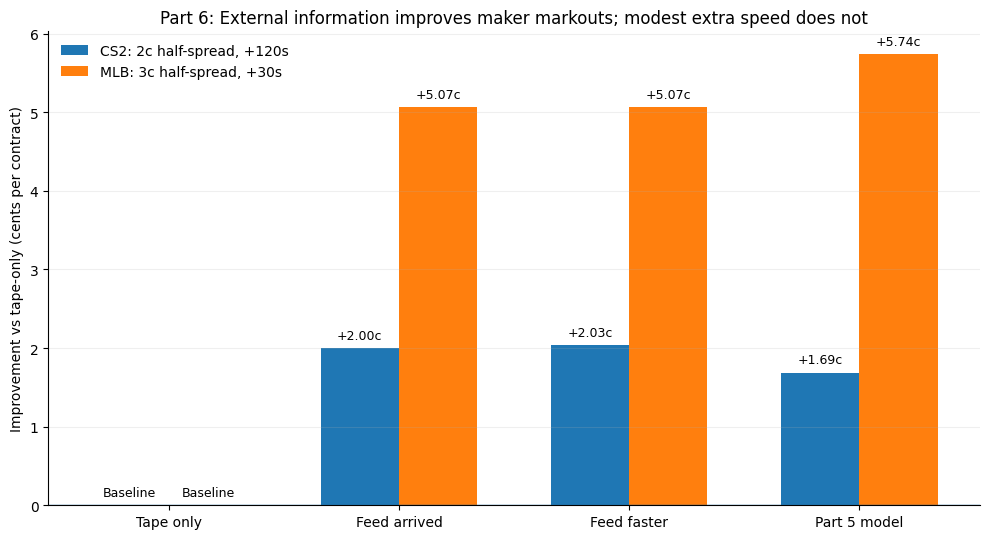

In [41]:

# Representative within-sport operating points used in the presentation:
# CS2: 2c half-spread, +120s markout
# MLB: 3c half-spread, +30s markout

def policy_value(df, policy, spread_c, col):
    return float(
        df.loc[
            df["policy"].eq(policy)
            & df["half_spread_c"].eq(spread_c),
            col
        ].iloc[0]
    )

summary = pd.DataFrame({
    "policy": ["Tape only", "Feed arrived", "Feed faster", "Part 5 model"],
    "CS2": [
        policy_value(cs2_four_policy, p, 2.0, "pnl_120_c")
        for p in ["Tape only", "Feed arrived", "Feed faster", "Part 5 model"]
    ],
    "MLB": [
        policy_value(mlb_four_policy, p, 3.0, "pnl_30_c")
        for p in ["Tape only", "Feed arrived", "Feed faster", "Part 5 model"]
    ]
})

summary["CS2_improvement"] = summary["CS2"] - summary.loc[0, "CS2"]
summary["MLB_improvement"] = summary["MLB"] - summary.loc[0, "MLB"]

display(summary)

x = np.arange(len(summary))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(
    x - width / 2,
    summary["CS2_improvement"],
    width,
    label="CS2: 2c half-spread, +120s"
)
b2 = ax.bar(
    x + width / 2,
    summary["MLB_improvement"],
    width,
    label="MLB: 3c half-spread, +30s"
)

for bars in [b1, b2]:
    for bar in bars:
        value = bar.get_height()
        label = "Baseline" if abs(value) < 1e-12 else f"+{value:.2f}c"
        ax.text(
            bar.get_x() + bar.get_width()/2,
            value + 0.08,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(summary["policy"])
ax.set_ylabel("Improvement vs tape-only (cents per contract)")
ax.set_title("Part 6: External information improves maker markouts; modest extra speed does not")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 8. Reference headline outputs

A clean run should reproduce approximately:

- Part 4 CS2 match-winner parity: **0.184 s**; RoundWon parity: **0.675 s**; MLB headline parity shifts: **0 s**.
- Part 5 directional TEST R² at 30 s: CS2 **0.458%**, MLB **−0.042%**.
- Part 5 magnitude TEST R² at 30 s: CS2 **6.731%**, MLB **6.395%**.
- MLB hazard model: TEST AUC **0.752**; TRAIN-frozen cancel threshold **0.086449**; TEST flag share **18.9%**; captures **50.6%** of >2c moves.
- Part 6 CS2 tape-only, 2c, +120 s: **−2.147c/contract**; feed-arrived: **−0.146c**; faster feed: **−0.113c**.
- Part 6 MLB tape-only, 3c, +30 s: **−6.449c/contract**; feed-arrived: **−1.384c**; Part 5 model: **−0.705c**.

These numbers are checks, not inputs to the analysis.


## 9. Reproducibility checks

These are intentionally tolerant to tiny library/version differences. A failure should be investigated rather than bypassed.


In [42]:
# Verify the Part 5 target universe matches the original reported analysis.
_target_expected = {
    ("CS2 TRAIN", 10): 175704,
    ("CS2 TRAIN", 30): 168702,
    ("CS2 TEST", 10): 88696,
    ("CS2 TEST", 30): 84456,
    ("MLB TRAIN", 10): 428063,
    ("MLB TRAIN", 30): 423473,
    ("MLB TEST", 10): 269153,
    ("MLB TEST", 30): 267923,
}

_target_frames = {
    "CS2 TRAIN": cs2_p5_train,
    "CS2 TEST": cs2_p5_test,
    "MLB TRAIN": mlb_p5_train,
    "MLB TEST": mlb_p5_test,
}

for (name, h), expected in _target_expected.items():
    got = int(_target_frames[name][f"y_{h}"].notna().sum())
    assert got == expected, (name, h, got, expected)


# Part 5 magnitude results
_expected_mag = {
    ("CS2", 10): 4.866,
    ("CS2", 30): 6.731,
    ("MLB", 10): 4.817,
    ("MLB", 30): 6.395,
}

for (sport, h), expected in _expected_mag.items():
    got = float(
        magnitude_results.loc[
            magnitude_results["sport"].eq(sport)
            & magnitude_results["feed"].eq("arrived")
            & magnitude_results["horizon_s"].eq(h),
            "test_r2_pct"
        ].iloc[0]
    )
    assert abs(got - expected) < 0.15, (sport, h, got, expected)

# Part 6 tape-only sanity checks
_cs2_2 = policy_value(cs2_four_policy, "Tape only", 2.0, "pnl_120_c")
_mlb_3 = policy_value(mlb_four_policy, "Tape only", 3.0, "pnl_30_c")
assert abs(_cs2_2 - (-2.147)) < 0.10, _cs2_2
assert abs(_mlb_3 - (-6.449)) < 0.20, _mlb_3

# Key policy result checks
_cs2_arr = policy_value(cs2_four_policy, "Feed arrived", 2.0, "pnl_120_c")
_cs2_fast = policy_value(cs2_four_policy, "Feed faster", 2.0, "pnl_120_c")
_mlb_model = policy_value(mlb_four_policy, "Part 5 model", 3.0, "pnl_30_c")

assert abs(_cs2_arr - (-0.146)) < 0.10, _cs2_arr
assert abs(_cs2_fast - (-0.113)) < 0.10, _cs2_fast
assert abs(_mlb_model - (-0.705)) < 0.15, _mlb_model

print("Reproducibility checks passed.")


Reproducibility checks passed.


# 10. Extra analysis (exploratory) — potential MLB pitch-release edge

**This section is explicitly exploratory and is not used to fit, tune, or validate the core homework results above.** The core reproducibility checks remain unchanged.

The hypothesis comes from the Part 3/4 timing work: Sportradar reports a **Pitch release** event before Kalshi fully reprices. The key question is whether that lead is economically useful as a **quote-protection / adverse-selection signal**.

This section tests three increasingly practical questions:

1. **Risk uplift:** Is a large next-10s move more likely immediately after a pitch release?
2. **Timing concentration:** How much large-move risk is concentrated inside 1s, 2s, 3s, and 5s post-pitch windows?
3. **Fill toxicity:** Among the Part 6 Sportradar maker fills, are fills shortly after pitch release worse than fills outside those windows?

Important interpretation constraint: **Pitch release is nondirectional.** These tests evaluate a defensive liquidity-management edge (when to step away), not a proven directional trading edge.


In [43]:
# 10.1 Snapshot of the existing evidence behind the pitch-release hypothesis

pitch_event_study = (
    part3_ranking[
        part3_ranking["feature"].eq("MLB Pitch release")
    ][["feature", "tape_t50", "touch_t50"]]
    .copy()
)

pitch_hazard_coef = float(
    hazard_coef.loc[
        hazard_coef["feature"].eq("recent_pitch_release_5s"),
        "coef"
    ].iloc[0]
)

pitch_edge_snapshot = pitch_event_study.copy()
pitch_edge_snapshot["hazard_std_coef"] = pitch_hazard_coef
pitch_edge_snapshot["interpretation"] = (
    "Timing / adverse-selection hypothesis; pitch release itself is nondirectional"
)

display(pitch_edge_snapshot)


,feature,tape_t50,touch_t50,hazard_std_coef,interpretation
3,MLB Pitch release,3.850769,3.292898,0.208073,Timing / adverse-selection hypothesis; pitch r...


In [44]:
# 10.2 Does large-move risk rise immediately after pitch release?

pitch_test = mlb_hazard_test[
    mlb_hazard_test["y_10"].notna()
].copy()

pitch_test["abs_move_10"] = pitch_test["y_10"].abs()
pitch_test["abs_move_30"] = pitch_test["y_30"].abs()
pitch_test["large_move_10"] = (
    pitch_test["abs_move_10"] > 0.02
).astype(int)

pitch_test["pitch_window"] = np.where(
    pitch_test["recent_pitch_release_5s"].eq(1),
    "Within 5s after pitch release",
    "Other times"
)

pitch_risk_uplift = (
    pitch_test
    .groupby("pitch_window", as_index=False)
    .agg(
        rows=("large_move_10", "size"),
        matches=("match_id", "nunique"),
        jump_rate_10=("large_move_10", "mean"),
        mean_abs_move_10=("abs_move_10", "mean"),
        median_abs_move_10=("abs_move_10", "median"),
        mean_abs_move_30=("abs_move_30", "mean")
    )
)

pitch_risk_uplift["jump_rate_10_pct"] = (
    100 * pitch_risk_uplift["jump_rate_10"]
)
pitch_risk_uplift["mean_abs_move_10_c"] = (
    100 * pitch_risk_uplift["mean_abs_move_10"]
)
pitch_risk_uplift["median_abs_move_10_c"] = (
    100 * pitch_risk_uplift["median_abs_move_10"]
)
pitch_risk_uplift["mean_abs_move_30_c"] = (
    100 * pitch_risk_uplift["mean_abs_move_30"]
)

recent_rate = float(
    pitch_risk_uplift.loc[
        pitch_risk_uplift["pitch_window"].eq(
            "Within 5s after pitch release"
        ),
        "jump_rate_10"
    ].iloc[0]
)

other_rate = float(
    pitch_risk_uplift.loc[
        pitch_risk_uplift["pitch_window"].eq("Other times"),
        "jump_rate_10"
    ].iloc[0]
)

pitch_risk_ratio = (
    recent_rate / other_rate
    if other_rate > 0
    else np.nan
)

print(
    "Pitch-release 5s jump-risk ratio vs other times:",
    f"{pitch_risk_ratio:.2f}x"
)

display(
    pitch_risk_uplift[
        [
            "pitch_window",
            "rows",
            "matches",
            "jump_rate_10_pct",
            "mean_abs_move_10_c",
            "median_abs_move_10_c",
            "mean_abs_move_30_c"
        ]
    ]
)


Pitch-release 5s jump-risk ratio vs other times: 2.14x


,pitch_window,rows,matches,jump_rate_10_pct,mean_abs_move_10_c,median_abs_move_10_c,mean_abs_move_30_c
0,Other times,227013,31,5.763987,0.447584,0.0,1.104951
1,Within 5s after pitch release,42140,31,12.325581,0.808412,0.0,1.539426


,rule,cancel_share_pct,jumps_removed_pct,jump_rate_cancelled_pct,jump_rate_kept_pct,risk_ratio_cancel_vs_keep
0,Pitch release: cancel 1s,3.111985,7.752065,16.917383,6.466061,2.616335
1,Pitch release: cancel 2s,6.237345,14.344330,15.618299,6.204109,2.517412
2,Pitch release: cancel 3s,9.369764,19.754910,14.318569,6.013102,2.381228
3,Pitch release: cancel 5s,15.656522,28.415121,12.325581,5.763987,2.138378
4,Full hazard model,18.676291,50.360742,15.446990,3.496636,4.417671


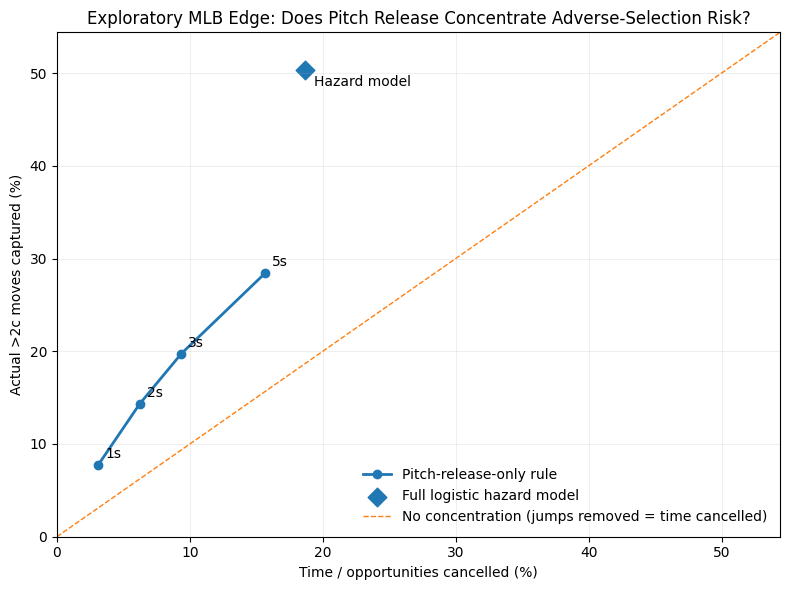

In [45]:
# 10.3 Pitch-only cancellation tradeoff by post-pitch window
# This asks: if we pulled both sides for W seconds after each pitch release,
# what fraction of time would we be off-market, and what fraction of actual
# >2c next-10s moves would fall inside those windows?

pitch_cancel_rows = []

pitch_age = pitch_test["pitch_release_age_s"].to_numpy(float)
jump = pitch_test["large_move_10"].to_numpy(int)

for window_s in [1, 2, 3, 5]:
    cancel = (
        np.isfinite(pitch_age)
        & (pitch_age >= 0)
        & (pitch_age <= window_s)
    )
    keep = ~cancel

    jump_rate_cancel = (
        jump[cancel].mean()
        if cancel.any()
        else np.nan
    )
    jump_rate_keep = (
        jump[keep].mean()
        if keep.any()
        else np.nan
    )

    pitch_cancel_rows.append({
        "rule": f"Pitch release: cancel {window_s}s",
        "window_s": window_s,
        "cancel_share": cancel.mean(),
        "jump_rate_cancelled": jump_rate_cancel,
        "jump_rate_kept": jump_rate_keep,
        "risk_ratio_cancel_vs_keep": (
            jump_rate_cancel / jump_rate_keep
            if pd.notna(jump_rate_keep) and jump_rate_keep > 0
            else np.nan
        ),
        "share_of_all_jumps_removed": (
            jump[cancel].sum() / jump.sum()
            if jump.sum() > 0
            else np.nan
        )
    })

pitch_cancel_tradeoff = pd.DataFrame(pitch_cancel_rows)

# Add the full logistic hazard model as a benchmark.
hazard_benchmark = pd.DataFrame([{
    "rule": "Full hazard model",
    "window_s": np.nan,
    "cancel_share": float(
        hazard_test_summary["cancel_share"].iloc[0]
    ),
    "jump_rate_cancelled": float(
        hazard_test_summary["jump_rate_cancelled"].iloc[0]
    ),
    "jump_rate_kept": float(
        hazard_test_summary["jump_rate_kept"].iloc[0]
    ),
    "risk_ratio_cancel_vs_keep": float(
        hazard_test_summary["risk_ratio_cancel_vs_keep"].iloc[0]
    ),
    "share_of_all_jumps_removed": float(
        hazard_test_summary["share_of_all_jumps_removed"].iloc[0]
    )
}])

pitch_vs_hazard_tradeoff = pd.concat(
    [pitch_cancel_tradeoff, hazard_benchmark],
    ignore_index=True
)

pitch_vs_hazard_tradeoff["cancel_share_pct"] = (
    100 * pitch_vs_hazard_tradeoff["cancel_share"]
)
pitch_vs_hazard_tradeoff["jumps_removed_pct"] = (
    100 * pitch_vs_hazard_tradeoff["share_of_all_jumps_removed"]
)
pitch_vs_hazard_tradeoff["jump_rate_cancelled_pct"] = (
    100 * pitch_vs_hazard_tradeoff["jump_rate_cancelled"]
)
pitch_vs_hazard_tradeoff["jump_rate_kept_pct"] = (
    100 * pitch_vs_hazard_tradeoff["jump_rate_kept"]
)

display(
    pitch_vs_hazard_tradeoff[
        [
            "rule",
            "cancel_share_pct",
            "jumps_removed_pct",
            "jump_rate_cancelled_pct",
            "jump_rate_kept_pct",
            "risk_ratio_cancel_vs_keep"
        ]
    ]
)

# Visual: an efficient cancel rule sits well above the diagonal — it removes
# more dangerous jumps than the fraction of time it removes from the market.
fig, ax = plt.subplots(figsize=(8, 6))

pitch_only = pitch_vs_hazard_tradeoff[
    pitch_vs_hazard_tradeoff["rule"].str.startswith("Pitch release")
].copy()

ax.plot(
    pitch_only["cancel_share_pct"],
    pitch_only["jumps_removed_pct"],
    marker="o",
    linewidth=2,
    label="Pitch-release-only rule"
)

haz = pitch_vs_hazard_tradeoff[
    pitch_vs_hazard_tradeoff["rule"].eq("Full hazard model")
].iloc[0]

ax.scatter(
    [haz["cancel_share_pct"]],
    [haz["jumps_removed_pct"]],
    s=90,
    marker="D",
    label="Full logistic hazard model"
)

for _, r in pitch_only.iterrows():
    ax.annotate(
        f'{int(r["window_s"])}s',
        (r["cancel_share_pct"], r["jumps_removed_pct"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.annotate(
    "Hazard model",
    (haz["cancel_share_pct"], haz["jumps_removed_pct"]),
    xytext=(6, -12),
    textcoords="offset points"
)

max_axis = max(
    5,
    1.08 * pitch_vs_hazard_tradeoff[
        ["cancel_share_pct", "jumps_removed_pct"]
    ].to_numpy().max()
)

ax.plot(
    [0, max_axis],
    [0, max_axis],
    linestyle="--",
    linewidth=1,
    label="No concentration (jumps removed = time cancelled)"
)

ax.set_xlim(0, max_axis)
ax.set_ylim(0, max_axis)
ax.set_xlabel("Time / opportunities cancelled (%)")
ax.set_ylabel("Actual >2c moves captured (%)")
ax.set_title(
    "Exploratory MLB Edge: Does Pitch Release Concentrate Adverse-Selection Risk?"
)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


,half_spread_c,pitch_cancel_window_s,contract_share_in_window_pct,pnl30_pitch_window_c,pnl30_outside_window_c,pnl30_filter_improvement_c,pnl120_pitch_window_c,pnl120_outside_window_c,pnl120_filter_improvement_c
0,1.0,1,8.318722,-6.238700,-0.566545,0.480760,-4.656969,-0.292743,0.358273
1,1.0,2,16.685259,-5.405134,-0.159103,0.888202,-4.470754,0.109690,0.760706
2,1.0,3,21.549522,-4.616736,-0.052423,0.994882,-3.611120,0.148104,0.799120
3,1.0,5,29.022485,-3.864181,0.120466,1.167772,-3.421813,0.454219,1.105235
4,2.0,1,9.248329,-9.109569,-0.375521,0.811408,-7.951505,0.400769,0.746346
5,2.0,2,17.288184,-6.993204,0.033181,1.220111,-5.976688,0.790364,1.135941
6,2.0,3,22.307564,-6.086830,0.226050,1.412979,-5.194421,0.994810,1.340388
7,2.0,5,29.220707,-5.103380,0.433286,1.620216,-4.501557,1.326238,1.671815
8,3.0,1,8.124390,-7.535650,-0.836627,0.547272,-6.201080,-0.047142,0.483740
9,3.0,2,16.437646,-6.254345,-0.416386,0.967512,-5.211780,0.359113,0.889996


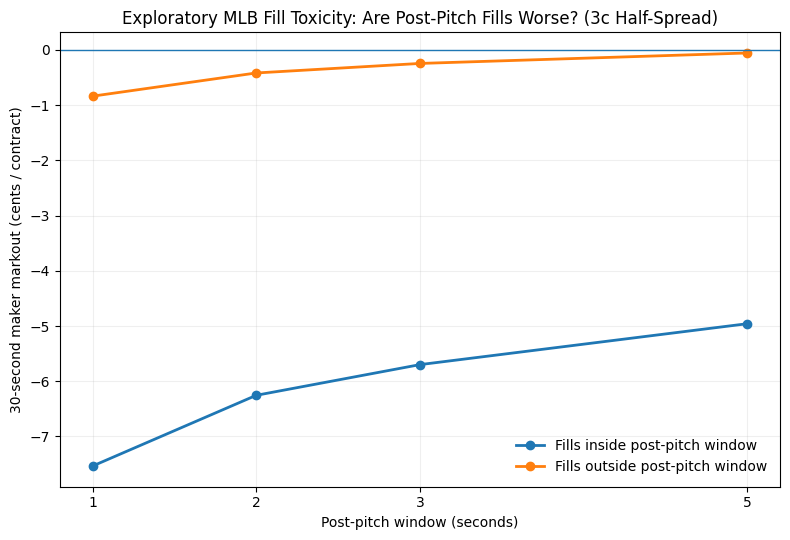

In [46]:
# 10.4 Are actual maker fills after pitch release more toxic?
# IMPORTANT: This is a post-hoc fill-toxicity diagnostic, not a full resimulation.
# Removing fills would change future queue/re-entry dynamics, so treat this as
# evidence for a candidate cancel rule rather than as realized strategy P&L.


def attach_pitch_age_to_fills(fills):
    x = fills.copy().reset_index(drop=True)

    if len(x) == 0:
        x["pitch_age_s"] = np.nan
        return x

    matched = starter.asof(
        left=x[["match_id", "t_ns"]],
        right=event_tables["pitch_release"],
        left_t="t_ns",
        right_t="t_recv_ns",
        by="match_id",
        shift_s=0,
        cols=["event_time_ns"]
    ).reset_index(drop=True)

    x["pitch_age_s"] = (
        x["t_ns"].to_numpy(float)
        - matched["event_time_ns"].to_numpy(float)
    ) / 1e9

    return x


pitch_fill_rows = []

for half_spread, fills in mlb_arrived_fills.items():
    f = attach_pitch_age_to_fills(fills)

    all_30 = weighted_cluster_pnl(f, "pnl_book_30")
    all_120 = weighted_cluster_pnl(f, "pnl_book_120")
    total_contracts = f["size"].sum()

    for window_s in [1, 2, 3, 5]:
        recent = (
            f["pitch_age_s"].notna()
            & f["pitch_age_s"].between(
                0,
                window_s,
                inclusive="both"
            )
        )

        removed = f[recent].copy()
        kept = f[~recent].copy()

        removed_30 = weighted_cluster_pnl(
            removed,
            "pnl_book_30"
        )
        kept_30 = weighted_cluster_pnl(
            kept,
            "pnl_book_30"
        )
        removed_120 = weighted_cluster_pnl(
            removed,
            "pnl_book_120"
        )
        kept_120 = weighted_cluster_pnl(
            kept,
            "pnl_book_120"
        )

        pitch_fill_rows.append({
            "half_spread_c": 100 * half_spread,
            "pitch_cancel_window_s": window_s,
            "contracts_total": total_contracts,
            "contracts_in_window": removed["size"].sum(),
            "contract_share_in_window": (
                removed["size"].sum() / total_contracts
                if total_contracts > 0
                else np.nan
            ),
            "pnl30_all_c": all_30["pnl_c"],
            "pnl30_pitch_window_c": removed_30["pnl_c"],
            "pnl30_outside_window_c": kept_30["pnl_c"],
            "pnl30_filter_improvement_c": (
                kept_30["pnl_c"] - all_30["pnl_c"]
            ),
            "pnl120_all_c": all_120["pnl_c"],
            "pnl120_pitch_window_c": removed_120["pnl_c"],
            "pnl120_outside_window_c": kept_120["pnl_c"],
            "pnl120_filter_improvement_c": (
                kept_120["pnl_c"] - all_120["pnl_c"]
            )
        })

pitch_fill_toxicity = pd.DataFrame(pitch_fill_rows)
pitch_fill_toxicity["contract_share_in_window_pct"] = (
    100 * pitch_fill_toxicity["contract_share_in_window"]
)

display(
    pitch_fill_toxicity[
        [
            "half_spread_c",
            "pitch_cancel_window_s",
            "contract_share_in_window_pct",
            "pnl30_pitch_window_c",
            "pnl30_outside_window_c",
            "pnl30_filter_improvement_c",
            "pnl120_pitch_window_c",
            "pnl120_outside_window_c",
            "pnl120_filter_improvement_c"
        ]
    ].sort_values(
        ["half_spread_c", "pitch_cancel_window_s"]
    )
)

# Compact visual for the 3c operating point used in the Part 6 presentation.
pitch_fill_3c = pitch_fill_toxicity[
    pitch_fill_toxicity["half_spread_c"].eq(3.0)
].copy()

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    pitch_fill_3c["pitch_cancel_window_s"],
    pitch_fill_3c["pnl30_pitch_window_c"],
    marker="o",
    linewidth=2,
    label="Fills inside post-pitch window"
)
ax.plot(
    pitch_fill_3c["pitch_cancel_window_s"],
    pitch_fill_3c["pnl30_outside_window_c"],
    marker="o",
    linewidth=2,
    label="Fills outside post-pitch window"
)

ax.axhline(0, linewidth=1)
ax.set_xticks([1, 2, 3, 5])
ax.set_xlabel("Post-pitch window (seconds)")
ax.set_ylabel("30-second maker markout (cents / contract)")
ax.set_title(
    "Exploratory MLB Fill Toxicity: Are Post-Pitch Fills Worse? (3c Half-Spread)"
)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


We found a potential MLB quote-protection edge around pitch release. Sportradar reports pitch release roughly three seconds before the Kalshi touch reaches its median response, and fills immediately after pitch release are dramatically more adversely selected. At a 2¢ half-spread, fills within one second of pitch release lose about 9.1¢ at the 30-second mark versus only 0.38¢ for other fills. A simple post-pitch blackout appears capable of removing a highly toxic subset of fills. This is exploratory and the next step is to rerun the queue simulation with the cancellation rule explicitly implemented.